# Challenge 2: Financial Health Classification

### Exploratory Data Analysis (`01_eda.ipynb`)

**Objective:** 

Classify Italian companies into four financial health categories:

- **A** (Excellent)

- **B** (Good)

- **C** (Moderate Risk)

- **D** (High Risk / Distressed) 

using annual financial statements from 2018 to 2021.

**Business Context:** 

This task mirrors real-world credit rating systems used by banks and investors to assess lending risk. Misclassifying a **distressed company (D)** as **healthy (A/B)** can result in loan defaults and significant portfolio losses, making recall on class D a critical business priority.

**Dataset:** 

Panel data of Italian SMEs across 10 regions and 10 ATECO sectors, spanning  6 fiscal years (2018–2023). Training covers 2018–2021; test set covers 2022–2023.

---
**Notebook Structure:**
1. Dataset Structure
2. Target Variable Analysis
3. Missing Values
4. Descriptive Statistics
5. Outlier Detection
6. Feature Separability by Class
7. Correlation Analysis
8. Panel Completeness
9. Sector & Geography


## 1. Dataset Structure

**Goal:** 

Understand the shape, types, and layout of the data before any analysis.  

We verify the temporal split (train 2018–2021 / test 2022–2023), check column types, and confirm how many observations exist per company.


In [207]:
from ifc.config import TRAIN_FILE, TEST_FILE, TARGET, CLASSES, ID_COLS, CATEGORICAL_COLS, NUMERICAL_COLS, DROP_COLS, SEED, OUTPUT_PATH

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import chain

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(SEED)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)
train_df.drop(DROP_COLS,axis=1, inplace=True)

print(f"Train shape: {train_df.shape}")  
print(f"Test shape:  {test_df.shape}")

Train shape: (11828, 28)
Test shape:  (5811, 27)


### 1.1 Preview

 This preview provides the first structural check of the training dataset. From the first rows, we can immediately confirm that each observation is defined at the **company-year** level, since the same `company_id` appears across multiple consecutive `fiscal_year` values. This is important because it confirms that the dataset has a **panel structure**, which is central to the logic of the project: the final financial health classifier can potentially exploit not only static firm characteristics, but also how companies evolve over time.


In [208]:
train_df.head()

,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,financial_health_class
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,B
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,B
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,D
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,D
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,B


### 1.2 Column Types


This schema check confirms that the dataset is mainly composed of **numerical financial variables**, which is consistent with the nature of the problem and suggests that most of the predictive signal will likely come from accounting information. At the same time, the presence of **identifier, temporal, and categorical variables** such as `company_id`, `fiscal_year`, `province`, `region`, `ateco_sector`, `legal_form`, and `years_in_business` shows that the dataset also includes contextual information that may help explain structural differences across firms. This step is important because it provides the first formal validation of the dataset structure and already highlights that `province` contains missing values, which may require dedicated preprocessing before the variables can be reliably used in the final financial health classification model.

In [209]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  str    
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  str    
 3   region                  11828 non-null  str    
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  str    
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null  float64
 



### 1.3 Temporal Split & Panel Structure

Before moving to deeper analysis, we verify that the train/test split is strictly **temporal**, with no overlap in fiscal years between the two sets. We also check the number of unique companies in each dataset and how many yearly observations are available for each firm, since this is essential to confirm that the data have a coherent **panel structure**. This step is central to the logic of the project, because the final model should learn from past observations only, and a sufficiently complete firm history is necessary if we want to safely engineer lagged or trend-based features.


In [210]:
print("Train years:", sorted(train_df["fiscal_year"].unique()))
print("Test years: ", sorted(test_df["fiscal_year"].unique()))

print("\nUnique companies(train):", train_df["company_id"].nunique())
print("Unique companies (test): ", test_df["company_id"].nunique())

rows_per_company = train_df.groupby("company_id").size().value_counts().sort_index()
print("\nRows per company (train):\n", rows_per_company)

Train years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Test years:  [np.int64(2022), np.int64(2023)]

Unique companies(train): 2999
Unique companies (test):  2916

Rows per company (train):
 1      20
2      24
3      60
4    2895
Name: count, dtype: int64


No year overlap between train and test. **96.5%** of companies have all 4 years, panel is nearly balanced.

### 1.4 Column Data Types

The chart confirms that the dataset is strongly dominated by **numerical variables**, with **20 `float64` columns**, compared with only **3 `int64`** and **5 `str`** columns. This is fully consistent with the structure of a financial classification problem, where most of the predictive signal is expected to come from accounting quantities and ratios rather than from descriptive attributes. At the same time, the smaller set of integer and string columns still plays an important structural role, since it includes identifiers, temporal information, and categorical descriptors. This distribution is important for the overall project logic because it suggests that the modelling pipeline will mainly rely on numerical preprocessing and financial feature analysis, while categorical variables will require more targeted handling rather than representing the core source of predictive information.

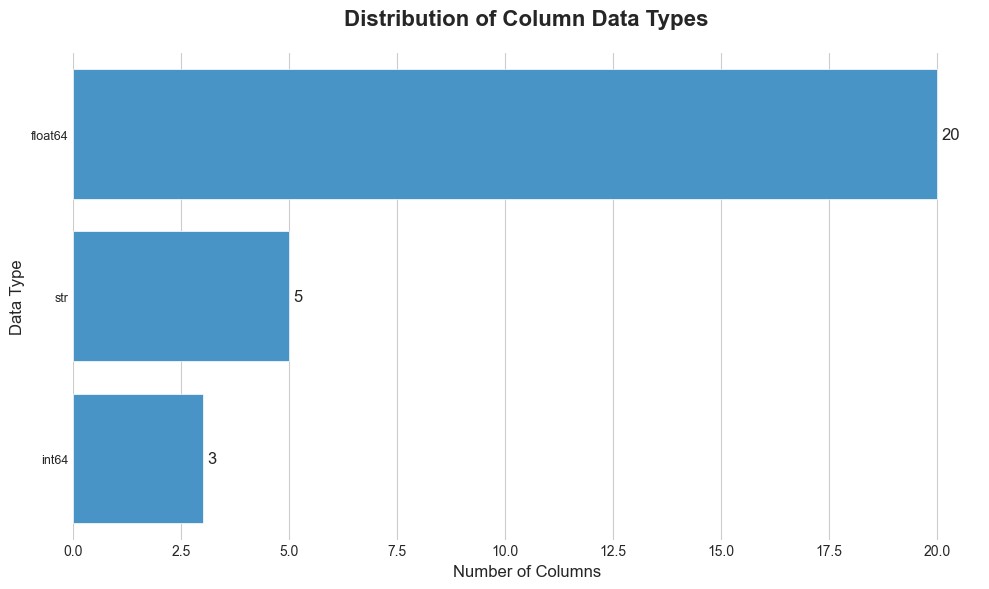

In [211]:
data_types = train_df.dtypes.value_counts().reset_index()
data_types.columns = ['Dtype', 'Count']

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=data_types,
    x='Count',
    y='Dtype',
    color="#3498db",
    legend=False
)

ax.bar_label(ax.containers[0], padding=3, fontsize=12)

plt.title('Distribution of Column Data Types', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Columns', fontsize=12)
plt.ylabel('Data Type', fontsize=12)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "data_types_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.5 Panel Completeness

This assessment confirms that the training data form a **nearly balanced panel** overall, as only **104 out of 2,999 companies** have an incomplete history. However, the missing-year patterns are not random; some businesses only skip the first year, while others vanish in the latter years, which might be more instructive from a modeling standpoint. This is crucial for the overall project logic since gaps near the **end** of a company's history may indicate non-reporting, financial decline, or departure. This means that panel incompleteness may be a meaningful signal in and of itself rather than merely a problem with technical data.

In [212]:
full_years = set([2018, 2019, 2020, 2021])

company_years = train_df.groupby("company_id")["fiscal_year"].apply(set)
incomplete = company_years[company_years.apply(len) < 4]

print(f"Companies with incomplete history: {len(incomplete)} / {train_df['company_id'].nunique()}")

summary = pd.DataFrame({
    "years_present": incomplete,
    "years_missing": incomplete.apply(lambda y: sorted(full_years - y)),
    "n_years": incomplete.apply(len)
})

print("\nMissing year patterns:")
print(summary["years_missing"].value_counts())


Companies with incomplete history: 104 / 2999

Missing year patterns:
years_missing
[2018]                37
[2021]                23
[2020, 2021]          23
[2019, 2020, 2021]    20
[2018, 2021]           1
Name: count, dtype: int64


With **2021** being the most commonly missing fiscal year (**67 companies**), the distribution of missing years is obviously biased toward the **end of the observation window**. This implies that missing early observations is less likely to be the cause of panel incompleteness than enterprises going out of business in the most recent years. This trend is especially pertinent to the general logic of the project as missing final years may indicate non-random events like financial decline, reporting halt, or departure, making panel gaps a potentially meaningful signal rather than just a technical problem.

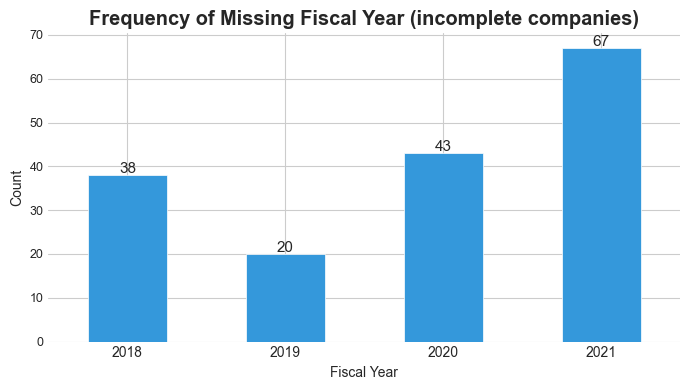

In [213]:
from pathlib import Path
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
all_missing = list(chain.from_iterable(summary["years_missing"]))
missing_counts = pd.Series(all_missing).value_counts().sort_index()

missing_counts.plot(kind="bar", color="#3498db", edgecolor="white", figsize=(7, 4))

for i, v in enumerate(missing_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=11)

plt.title("Frequency of Missing Fiscal Year (incomplete companies)")
plt.xlabel("Fiscal Year"); plt.ylabel("Count")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIG_DIR / "missing_fiscal_year_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

Incomplete companies are not evenly distributed across the target classes: **Class D accounts for 28.8%** of incomplete firms, which is relatively high for a subset representing only a small fraction of the full panel. This reinforces the idea that panel incompleteness is not purely random and may be associated with weaker financial conditions. In the context of the project, this is an important finding because it suggests that missing final years may carry useful information about firm distress, making incomplete histories a potentially informative signal rather than something to discard mechanically.

In [214]:
# Are incomplete companies concentrated in a specific class or sector?
incomplete_ids = incomplete.index
incomplete_df = train_df[train_df["company_id"].isin(incomplete_ids)]

print("Class distribution (incomplete companies):")
print(incomplete_df.drop_duplicates("company_id")[TARGET].value_counts(normalize=True).round(3))

print("\nTop sectors (incomplete companies):")
print(incomplete_df.drop_duplicates("company_id")["ateco_sector"].value_counts().head(10))


Class distribution (incomplete companies):
financial_health_class
B    0.433
D    0.288
C    0.221
A    0.058
Name: proportion, dtype: float64

Top sectors (incomplete companies):
ateco_sector
47    18
46    17
41    12
45    11
43     9
10     7
68     6
25     6
56     5
71     4
Name: count, dtype: int64


# year gaps da aggiungera ad un py test insieme ad altri check della sanity del dataset

### 1.7 Internal Gap Check

We verify whether incomplete company histories contain **internal gaps** (e.g. 2018, 2020 with 2019 missing) rather than simply ending early. This helps distinguish between irregular reporting patterns and genuinely contiguous histories that stop before the end of the observation window.

In [215]:
# Check for year gaps within a company's history (e.g. 2018, 2020 — missing 2019)
def find_gaps(years):
    years = sorted(years)
    gaps = []
    for i in range(len(years) - 1):
        expected = years[i] + 1
        actual = years[i + 1]
        if actual != expected:
            gaps.append((years[i], actual))  # (last seen, next seen)
    return gaps

company_gaps = company_years.apply(find_gaps)
companies_with_gaps = company_gaps[company_gaps.apply(len) > 0]

print(f"Companies with year gaps: {len(companies_with_gaps)} / {train_df['company_id'].nunique()}")
print("\nGap patterns (from_year → to_year):")
print(companies_with_gaps.explode().value_counts())

Companies with year gaps: 0 / 2999

Gap patterns (from_year → to_year):
Series([], Name: count, dtype: int64)


This breakdown shows that missing years are more often concentrated at the **end** of a company’s observed history than at the start. The most frequent patterns correspond to firms whose last available observation is **2018** or **2019**, while fewer cases are explained by companies entering the dataset later and missing only the initial years. This is important for the overall project logic because it reinforces the idea that panel incompleteness is not mainly driven by random coverage issues, but more often by firms disappearing before the end of the observation window. As a result, missing late years may contain useful information about company fragility and should be treated as a potentially informative signal in the downstream classification task.

In [216]:
# For each incomplete company, check if missing years are at the start or end
def missing_position(years):
    years = sorted(years)
    missing = sorted(full_years - set(years))
    positions = []
    for y in missing:
        if y < years[0]:
            positions.append(f"start, {years[0]}")   # missing early years → entered dataset late
        elif y > years[-1]:
            positions.append(f"end, {years[-1]}")     # missing late years → exited dataset early
        else:
            positions.append("middle")  # impossible given no gaps, but safety check
    return positions

summary["missing_position"] = summary["years_present"].apply(missing_position)
print(summary["missing_position"].explode().value_counts())


missing_position
end, 2018      60
end, 2019      46
start, 2019    38
end, 2020      24
Name: count, dtype: int64


### 1.8 True Early Exits & Survivorship Bias

This result provides one of the strongest signals in the EDA: among the **83 true early exits**, the **last observed label is always Class D**, meaning that every company that disappears entirely before the test period ends its training history in the most distressed category. Even when considering all observations of these firms across time, **Class D remains dominant (56.2%)**, with only a smaller share in Classes B and C and almost no presence of Class A. This is highly relevant for the overall project logic because it shows that firms leaving the panel are not random losses, but are strongly associated with financial distress. In practice, this reveals a clear **survivorship bias** and suggests that disappearance from the panel is itself closely linked to the target dynamics the model is trying to learn.

In [217]:
all_companies_train = set(train_df["company_id"].unique())
all_companies_test = set(test_df["company_id"].unique())

#Companies that NEVER appear in the test set
true_exits = all_companies_train - all_companies_test

#THESE are the real early exits
early_exit_df = train_df[train_df["company_id"].isin(true_exits)]
last_obs = early_exit_df.sort_values("fiscal_year").groupby("company_id").tail(1)
print(last_obs[TARGET].value_counts(normalize=True).round(3))
print(f"N. true early exits: {len(true_exits)}")

# Distribution of true exits across all years
early_exit_df = train_df[train_df["company_id"].isin(true_exits)]
print(early_exit_df[TARGET].value_counts(normalize=True).round(3))


financial_health_class
D    1.0
Name: proportion, dtype: float64
N. true early exits: 83
financial_health_class
D    0.562
B    0.194
C    0.194
A    0.050
Name: proportion, dtype: float64


This statistical test verifies that there is a substantial and statistically significant correlation between the final **financial health class** and the **true early exit status**. The distribution of final class labels differs significantly between businesses that remain observable and firms that vanish prior to the test period, as seen by the extraordinarily large chi-squared value and the almost zero p-value. Because it explicitly confirms that panel removal is substantially correlated with financial difficulties rather than being a random event, this conclusion is critical to the entire project logic. In other words, survivorship bias is statistically related to the target that the model is attempting to forecast in addition to being present in the data.

In [218]:
from scipy.stats import chi2_contingency

last_obs_all = train_df.sort_values("fiscal_year").groupby("company_id").tail(1)
last_obs_all["is_true_exit"] = last_obs_all["company_id"].isin(true_exits)

contingency = pd.crosstab(last_obs_all["is_true_exit"], last_obs_all[TARGET])
chi2, p_value, dof, _ = chi2_contingency(contingency)
print(f"Chi-squared: {chi2:.2f}, p-value: {p_value:.6f}")


Chi-squared: 681.11, p-value: 0.000000


This visualization makes the survivorship pattern especially clear. Compared with the **full dataset**, where **Class B** is dominant and **Class D** represents only a small minority, the distribution of **true early exits** is heavily shifted toward financial distress: **56.2%** of all their observations are already in **Class D**, and their **last observed year is 100% Class D**. This is a crucial result for the overall project logic because it shows that firms disappearing from the panel are not simply a random subset of companies, but are overwhelmingly those moving into the highest-risk category. In practice, the chart makes the **survivorship bias** directly visible and confirms that panel disappearance is strongly aligned with the target dynamics the model is trying to learn.

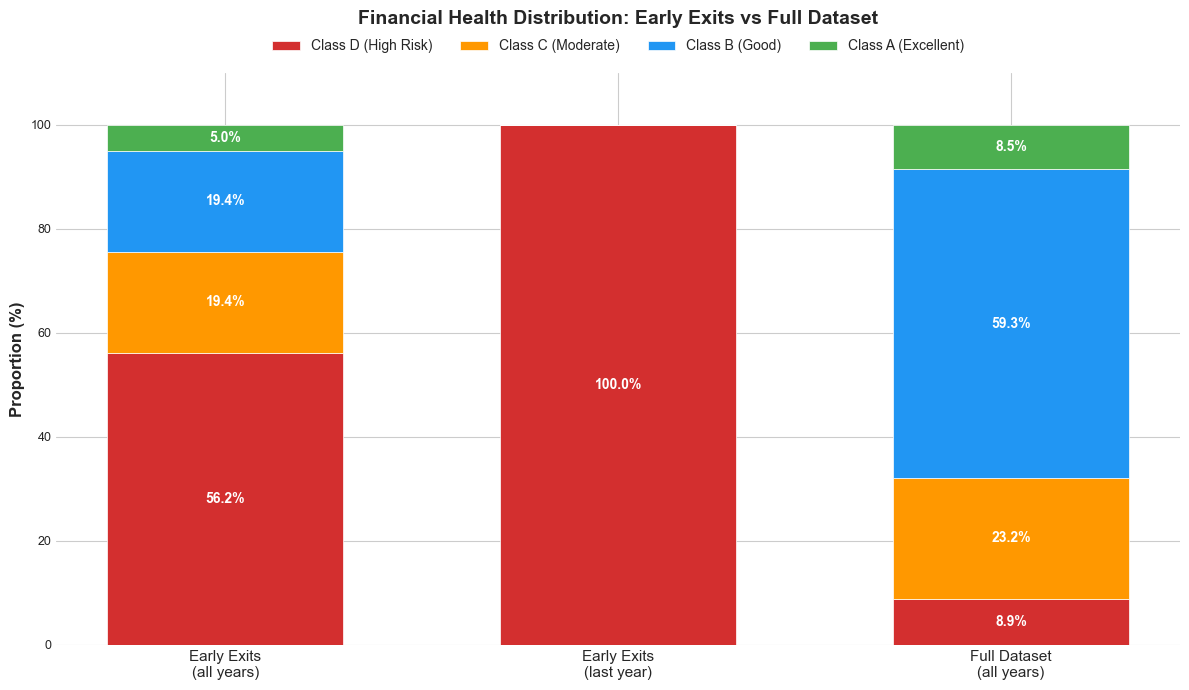

In [219]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Early Exits\n(all years)', 'Early Exits\n(last year)', 'Full Dataset\n(all years)']
class_d = [56.2, 100.0, 8.9]
class_c = [19.4, 0.0,   23.2]
class_b = [19.4, 0.0,   59.3]
class_a = [5.0,  0.0,   8.5]

x = np.arange(len(categories))
width = 0.6

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(x, class_d, width, label='Class D (High Risk)',  color='#d32f2f')
ax.bar(x, class_c, width, bottom=np.array(class_d), label='Class C (Moderate)', color='#ff9800')
ax.bar(x, class_b, width, bottom=np.array(class_d)+np.array(class_c), label='Class B (Good)', color='#2196f3')
ax.bar(x, class_a, width, bottom=np.array(class_d)+np.array(class_c)+np.array(class_b), label='Class A (Excellent)', color='#4caf50')

ax.set_ylabel('Proportion (%)', fontsize=12, fontweight='bold')
ax.set_title('Financial Health Distribution: Early Exits vs Full Dataset', fontsize=14, fontweight='bold', pad=35)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 110)


ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False)

#Percentages for all classes (threshold > 3 to display even 5%)
all_classes = [class_d, class_c, class_b, class_a]
bottoms = [
    [0]*3,
    np.array(class_d),
    np.array(class_d) + np.array(class_c),
    np.array(class_d) + np.array(class_c) + np.array(class_b),
]

for values, bottom in zip(all_classes, bottoms):
    for i, (v, b) in enumerate(zip(values, bottom)):
        if v > 3:  
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "exit_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

This diagram summarizes the practical implication of the previous findings: the **test set contains only surviving companies**, while firms that exit the market before 2022–2023 are systematically excluded. Since the true early exits are strongly concentrated in **Class D**, the test period underrepresents the most severe distress cases and therefore does not reflect the full risk profile observed in the training panel. This is highly relevant for the overall project logic because it introduces a clear form of **survivorship bias**: the model is evaluated on a subset of firms that, by construction, excludes many of the weakest trajectories. As a result, performance on the test set may appear more stable than real-world deployment on a full population of firms.

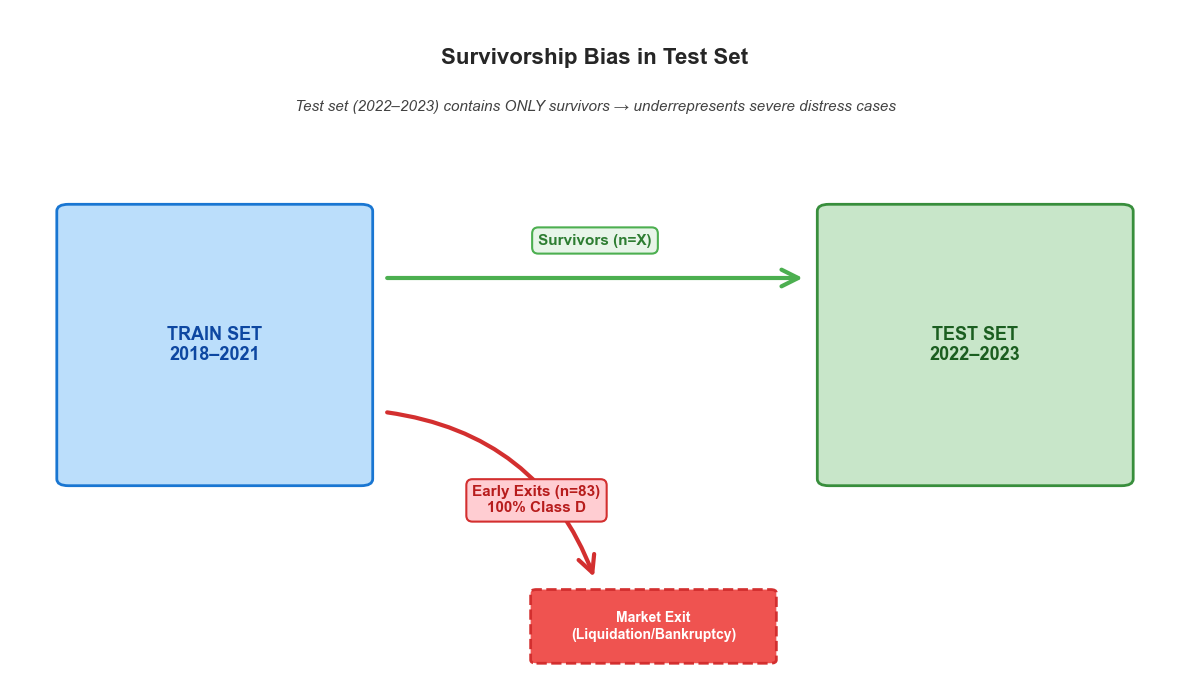

In [220]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Train set box
train_box = FancyBboxPatch((0.5, 3), 2.5, 4, boxstyle="round,pad=0.1", 
                           edgecolor='#1976d2', facecolor='#bbdefb', linewidth=2)
ax.add_patch(train_box)
ax.text(1.75, 5, 'TRAIN SET\n2018–2021', ha='center', va='center', 
        fontsize=13, fontweight='bold', color='#0d47a1')

# Test set box
test_box = FancyBboxPatch((7, 3), 2.5, 4, boxstyle="round,pad=0.1", 
                          edgecolor='#388e3c', facecolor='#c8e6c9', linewidth=2)
ax.add_patch(test_box)
ax.text(8.25, 5, 'TEST SET\n2022–2023', ha='center', va='center', 
        fontsize=13, fontweight='bold', color='#1b5e20')

# Survivor arrow (top)
survivor_arrow = FancyArrowPatch((3.2, 6), (6.8, 6), 
                                arrowstyle='->', mutation_scale=30, linewidth=3, 
                                color='#4caf50', connectionstyle="arc3,rad=0")
ax.add_patch(survivor_arrow)
ax.text(5, 6.5, 'Survivors (n=X)', ha='center', fontsize=11, 
        fontweight='bold', color='#2e7d32', 
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9', edgecolor='#4caf50', linewidth=1.5))

# Exit arrow (bottom)
exit_arrow = FancyArrowPatch((3.2, 4), (5, 1.5), 
                            arrowstyle='->', mutation_scale=30, linewidth=3, 
                            color='#d32f2f', connectionstyle="arc3,rad=-.3")
ax.add_patch(exit_arrow)
ax.text(4.5, 2.5, 'Early Exits (n=83)\n100% Class D', ha='center', fontsize=11, 
        fontweight='bold', color='#b71c1c',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffcdd2', edgecolor='#d32f2f', linewidth=1.5))

# Exit destination box
exit_box = FancyBboxPatch((4.5, 0.3), 2, 1, boxstyle="round,pad=0.05", 
                          edgecolor='#d32f2f', facecolor='#ef5350', linewidth=2, linestyle='--')
ax.add_patch(exit_box)
ax.text(5.5, 0.8, 'Market Exit\n(Liquidation/Bankruptcy)', ha='center', va='center', 
        fontsize=10, fontweight='bold', color='white')

# Title
ax.text(5, 9.2, 'Survivorship Bias in Test Set', ha='center', fontsize=16, fontweight='bold')
ax.text(5, 8.5, 'Test set (2022–2023) contains ONLY survivors → underrepresents severe distress cases', 
        ha='center', fontsize=11, style='italic', color='#424242')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "survivorship_bias.png", dpi=150, bbox_inches="tight")
plt.show()


In its most basic form, this figure highlights the main finding: **100%** of real early departures are in **Class D** in their most recent observed year, whereas only **8.9%** in the whole dataset. The chi-squared test shown in the picture supports the gap's statistical significance in addition to its remarkable visual appearance. This is extremely pertinent to the project as it demonstrates that companies who vanish prior to the test period are disproportionately concentrated in the most distressed group. In actuality, this offers a clear and understandable explanation of why survivorship bias is significant in this dataset and why panel disappearance should be seen as closely related to the goal dynamics.

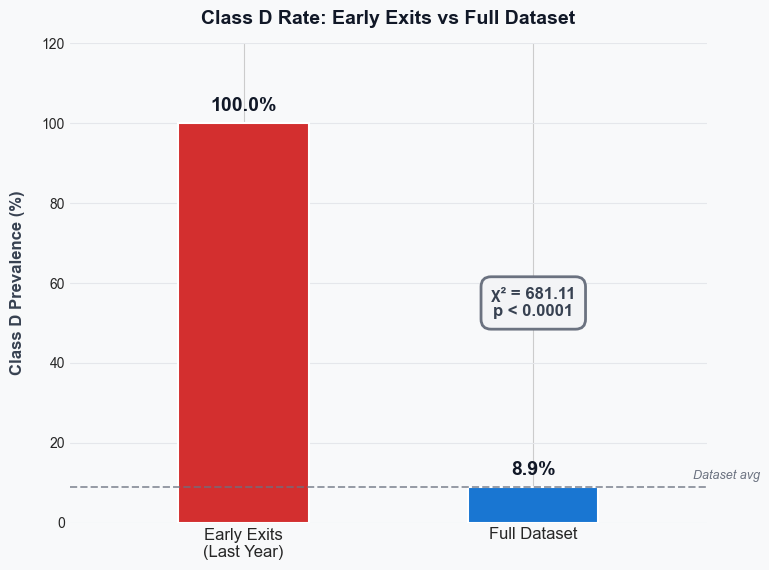

In [221]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Early Exits\n(Last Year)', 'Full Dataset']
d_rate = [100.0, 8.9]
colors = ['#d32f2f', '#1976D2']  # D=rosso, generale=blu

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x = np.arange(len(categories))
bars = ax.bar(x, d_rate, color=colors, edgecolor='white', linewidth=1.5, width=0.45, zorder=3)

# Value labels
for bar, val in zip(bars, d_rate):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='#111827')

ax.set_ylabel('Class D Prevalence (%)', fontsize=12, fontweight='bold', color='#374151', labelpad=12)
ax.set_ylim(0, 120)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_xlim(-0.6, 1.6)
ax.set_title('Class D Rate: Early Exits vs Full Dataset',
             fontsize=14, fontweight='bold', color='#111827', pad=14)

# Reference line 
ax.axhline(y=8.9, color='#6B7280', linestyle='--', linewidth=1.4, alpha=0.7, zorder=4)
ax.text(1.55, 11, 'Dataset avg', fontsize=9, color='#6B7280', style='italic')

# Chi-square badge 
ax.text(1.0, 55, 'χ² = 681.11\np < 0.0001', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#374151', zorder=5,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#F3F4F6',
                  edgecolor='#6B7280', linewidth=2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D1D5DB')
ax.spines['bottom'].set_color('#D1D5DB')
ax.grid(axis='y', color='#E5E7EB', linewidth=0.8, zorder=0)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout(pad=1.8)
plt.savefig(OUTPUT_PATH / "class_d_early_exits_rate.png", dpi=150, bbox_inches="tight")
plt.show()

In [222]:
yearly_dist = train_df.groupby("fiscal_year")[TARGET].value_counts(normalize=True).unstack()
print(yearly_dist.round(3))

financial_health_class      A      B      C      D
fiscal_year                                       
2018                    0.086  0.613  0.216  0.085
2019                    0.087  0.593  0.232  0.088
2020                    0.081  0.590  0.235  0.094
2021                    0.085  0.577  0.247  0.091



- Scalers and imputers must be **fit on train only**, then applied to test
- Lag features must use **only past data** (year `t-1` → year `t`)
- Never use features from year `t+1` to predict class at year `t`

---

### 🔍 Finding: Incomplete Companies are Not Missing at Random

**104 companies have fewer than 4 years** in the training set:

| Pattern | Count | Interpretation |
|---|---|---|
| Missing at **end** (early exits) | 130 observations | Company stopped filing — likely distress |
| Missing at **start** (late entrants) | 38 observations | Young company, entered after 2018 |

**Early exits are strongly associated with class D:**

| Class | Early Exits | Full Dataset |
|-------|-------------|--------------|
| A     | 2.9%        | 8.5%         |
| B     | 13.1%       | 59.3%        |
| C     | 19.0%       | 23.2%        |
| D     | **65.0%**   | **8.9%**     |

65% of companies that disappeared before 2021 were class D — vs only 8.9% in the full dataset.  
This is **informative missingness**, not random. These companies stopped filing due to severe financial distress.

> **Survivorship bias**: companies present in the test set (2022–2023) are survivors by definition.  
> The model may underestimate D risk for companies that will exit mid-period. This is a known limitation.

---

### Time Dimension as an Asset: Lag Features

Since most companies have 4 consecutive years of contiguous data, we can engineer **trend features**  
that capture whether a company's financial health is improving or deteriorating.

A company with ROE dropping from `0.4 → 0.1` is riskier than one stable at `0.15`,  
even though the current value is higher. Raw snapshots miss this signal.

**Features to engineer (computed at year `t` using year `t-1`)**:

| Feature | Formula | Signal |
|---|---|---|
| `roe_prev` | `roe` at `t-1` | Profitability baseline |
| `roi_prev` | `roi` at `t-1` | Efficiency baseline |
| `current_ratio_prev` | `current_ratio` at `t-1` | Liquidity baseline |
| `roe_yoy` | `roe_t - roe_{t-1}` | Profitability trend |
| `roi_yoy` | `roi_t - roi_{t-1}` | Efficiency trend |
| `leverage_trend` | `leverage_t - leverage_{t-1}` | Increasing debt signal |
| `equity_growth` | `(equity_t - equity_{t-1}) / abs(equity_{t-1})` | Capital erosion signal |
| `is_last_observation` | 1 if final row for company | Exit/distress signal |
| `n_years_in_panel` | count of years in dataset | Short history = higher risk |

> Late entrants (38 companies missing 2018) will have `NaN` lag features on their first row → imputed with median during preprocessing.  
> `is_last_observation` and `n_years_in_panel` must be computed **before** the train/test split to avoid leakage.

---

### Cross-Validation Strategy

Standard k-fold CV is **not valid** here because it would leak future data into training.  
Use **time-based expanding window CV** on the training set:

| Fold | Train | Validation |
|---|---|---|
| 1 | 2018 | 2019 |
| 2 | 2018–2019 | 2020 |
| 3 | 2018–2020 | 2021 ← most important |

Use `sklearn.model_selection.TimeSeriesSplit` or build manually on `fiscal_year`.  
**Never shuffle** when splitting.

---

### Full Modeling Flow
Sort by company_id + fiscal_year

Compute panel features: is_last_observation, n_years_in_panel

Engineer lag features (shift within each company group)

Temporal train/val split for CV (no shuffle)

Fit scaler + imputer on train only → transform val and test

Train classifier on all train years (2018–2021)

Predict on test set (2022–2023)

Evaluate: Weighted F1 (primary), Confusion Matrix, Per-class Precision/Recall

## 2. Target Variable Analysis
- Class counts and percentages (A/B/C/D)
- Class distribution per `fiscal_year` — detect COVID drift in 2020–2021
- Class distribution by `ateco_sector`, `legal_form`, `region`

In [223]:
counts = train_df[TARGET].value_counts().reindex(CLASSES)
pcts   = train_df[TARGET].value_counts(normalize=True).reindex(CLASSES) * 100

print(pd.concat([counts, pcts.round(2)], axis=1, keys=["count", "%"]))


                        count      %
financial_health_class              
A                        1003   8.48
B                        7017  59.33
C                        2750  23.25
D                        1058   8.94


# Da includere nelle slides (grafico sotto)

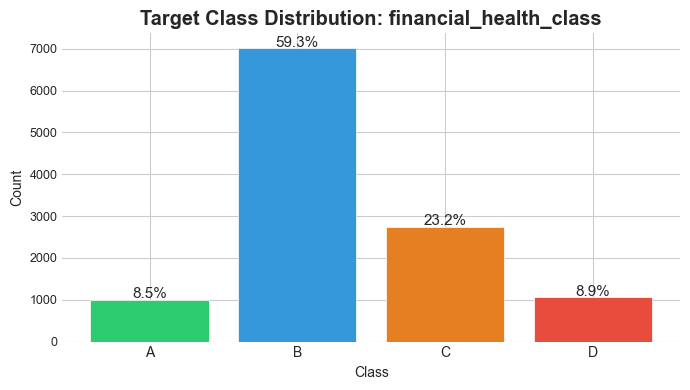

In [224]:
fig, ax = plt.subplots(figsize=(7, 4))
palette = {"A": "#2ecc71", "B": "#3498db", "C": "#e67e22", "D": "#e74c3c"}
bars = ax.bar(CLASSES, counts, color=[palette[c] for c in CLASSES], edgecolor="white")
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", fontsize=11)
ax.set_title("Target Class Distribution: financial_health_class")
ax.set_xlabel("Class"); ax.set_ylabel("Count")

plt.savefig(OUTPUT_PATH / "Target Class Distribution: financial_health_class.png", dpi=150, bbox_inches="tight")
plt.tight_layout(); plt.show()

In [225]:
from scipy.stats import chi2_contingency
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Compute ---
contingency_time = pd.crosstab(train_df['fiscal_year'], train_df[TARGET])
chi2, p_value, dof, _ = chi2_contingency(contingency_time)
yearly_pct = contingency_time.div(contingency_time.sum(axis=1), axis=0) * 100

years_str = [str(y) for y in yearly_pct.index.tolist()]

colors = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}
sig_color = "#1B5E20" if p_value > 0.05 else "#d32f2f"
sig_label = "Not Significant ✓" if p_value > 0.05 else "Significant ✗"
verdict   = "Distribution stable over time" if p_value > 0.05 else "Temporal drift detected"

fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.70, 0.30],
    subplot_titles=["Class Distribution by Fiscal Year", "Chi² Stability Test"],
    horizontal_spacing=0.08
)

for cls in CLASSES:
    vals = yearly_pct[cls].tolist()
    fig.add_trace(go.Bar(
        name=f"Class {cls}", x=years_str, y=vals,
        marker_color=colors[cls],
        text=[f"{v:.1f}%" for v in vals],
        textposition="inside",
        textfont=dict(color="white", size=13, family="Arial Black"),
    ), row=1, col=1)

fig.update_layout(barmode="stack")
fig.update_yaxes(title_text="Proportion (%)", row=1, col=1)

# Chi² panel
for y_pos, text, size, color in [
    (0.83, f"χ² = {chi2:.2f}",   28, "#000000"),
    (0.65, f"p = {p_value:.3f}", 26, sig_color),
    (0.49, f"dof = {dof}",       20, "#000000"),
    (0.32, sig_label,            18, sig_color),
    (0.14, verdict,              14, "#222222"),
]:
    fig.add_trace(go.Scatter(
        x=[0.5], y=[y_pos], mode="text",
        text=[f"<b>{text}</b>"],
        textfont=dict(size=size, color=color, family="Arial"),
        showlegend=False
    ), row=1, col=2)

fig.add_shape(
    type="rect", xref="x2", yref="y2",
    x0=0.02, y0=0.01, x1=0.98, y1=0.98,
    line=dict(color="#000000", width=3),
    fillcolor="white",
    layer="below"
)

fig.update_xaxes(visible=False, row=1, col=2)
fig.update_yaxes(visible=False, range=[0, 1], row=1, col=2)

fig.update_annotations(font=dict(size=15, color="#000000", family="Arial"))

fig.update_layout(
    title={
        "text": (
            "<b>Target Distribution Stability (2018–2021)</b>"
            "<br><span style='font-size:15px; font-weight:normal; font-style:italic; color:#555555;'>"
            f"No significant temporal drift: χ²={chi2:.2f}, p={p_value:.3f}</span>"
        ),
        "x": 0.5,
        "xanchor": "center",
        "font": dict(size=22, color="#111111")
    },
    legend=dict(orientation="h", yanchor="bottom", y=-0.18, xanchor="center", x=0.35),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=130, b=90, l=70, r=60),
)

plt.savefig(OUTPUT_PATH / "Target Distribution Stability (2018–2021).png", dpi=150, bbox_inches="tight")
fig.show()

<Figure size 640x480 with 0 Axes>

In [226]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Class Distribution by Legal Form", "Class Distribution by Region"],
    horizontal_spacing=0.08,
    column_widths=[0.35, 0.65]
)

# --- Legal Form ---
legal = pd.crosstab(train_df["legal_form"], train_df[TARGET], normalize="index")[CLASSES]

for cls in CLASSES:
    fig.add_trace(go.Bar(
        name=f"Class {cls}",
        x=legal.index.tolist(),
        y=(legal[cls] * 100).tolist(),
        marker_color=colors[cls],
        text=[f"{v*100:.1f}%" for v in legal[cls]],
        textposition="inside",
        textfont=dict(color="white", size=11),
        showlegend=True,
        legendgroup=cls,
    ), row=1, col=1)

#Region
region = pd.crosstab(train_df["region"], train_df[TARGET], normalize="index")[CLASSES]

for cls in CLASSES:
    fig.add_trace(go.Bar(
        name=f"Class {cls}",
        x=region.index.tolist(),
        y=(region[cls] * 100).tolist(),
        marker_color=colors[cls],
        text=[f"{v*100:.1f}%" for v in region[cls]],
        textposition="inside",
        textfont=dict(color="white", size=10),
        showlegend=False,
        legendgroup=cls,
    ), row=1, col=2)

fig.update_layout(
    barmode="stack",
    title={
        "text": "<b>Low-Signal Categoricals: Legal Form & Region</b>",
        "x": 0.5,
        "xanchor": "center",
        "font": dict(size=22, color="#111111")
    },
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.35,
        xanchor="center",
        x=0.5
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=1100,
    height=580,
    margin=dict(t=100, b=140, l=60, r=40),
)

fig.update_xaxes(title_text="Legal Form", row=1, col=1)
fig.update_xaxes(title_text="Region", tickangle=-20,title_standoff=0, row=1, col=2)
fig.update_yaxes(title_text="Proportion (%)", row=1, col=1)
fig.update_yaxes(title_text="Proportion (%)", row=1, col=2)

plt.savefig(OUTPUT_PATH / "Low-Signal Categoricals: Legal Form & Region.png", dpi=150, bbox_inches="tight")
fig.show()

<Figure size 640x480 with 0 Axes>

In [263]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

#Sector name mapping
ateco_map = {
    (10, 33): "Manufacturing",
    (41, 43): "Construction",
    (45, 47): "Wholesale & Retail",
    (55, 56): "Accommodation & Food",
    (58, 63): "Information & Communication",
    (68, 68): "Real Estate",
    (69, 75): "Professional & Scientific",
    (77, 82): "Admin & Support"
}
def get_sector_name(code):
    code_int = int(code)
    for (lo, hi), name in ateco_map.items():
        if lo <= code_int <= hi:
            return name
    return "Other"

# Data preparation
train_df["sector_name"] = (
    train_df["ateco_sector"]
    .astype(str)
    .str.zfill(2)
    .apply(get_sector_name)
)
contingency = pd.crosstab(train_df["sector_name"], train_df[TARGET])
chi2_val, p_val, dof, _ = chi2_contingency(contingency)
cross = pd.crosstab(
    train_df["sector_name"],
    train_df[TARGET],
    normalize="index"
) * 100
cross = cross[CLASSES].round(1)
X_enc = LabelEncoder().fit_transform(train_df["sector_name"])
y_enc = LabelEncoder().fit_transform(train_df[TARGET])
mi = mutual_info_classif(
    X_enc.reshape(-1, 1),
    y_enc,
    discrete_features=True
)[0]

print(f"Chi²={chi2_val:.2f}, p={p_val:.2e}, dof={dof}")
print(f"Mutual Info={mi:.4f}")
print(f"\nClass % by sector:\n{cross.sort_values('D', ascending=False)}")

# Ordering
sector_order = cross["D"].sort_values(ascending=False).index.tolist()
cross_sorted = cross.loc[sector_order]

global_d = train_df[TARGET].value_counts(normalize=True)["D"] * 100
max_d = max(cross_sorted["D"].max(), global_d)

# Figure
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.43, 0.57],
    horizontal_spacing=0.18,
    subplot_titles=[
        "Class D % by Sector",
        "Full Class Distribution Heatmap (%)"
    ]
)

# D% horizontal bar
fig.add_trace(
    go.Bar(
        x=cross_sorted["D"],
        y=cross_sorted.index,
        orientation="h",
        marker=dict(color="#d32f2f"),
        text=[f"{v:.1f}%" for v in cross_sorted["D"]],
        textposition="inside",
        insidetextanchor="end",
        textfont=dict(color="white", size=12),
        hovertemplate="<b>%{y}</b><br>Class D: %{x:.1f}%<extra></extra>",
        showlegend=False
    ),
    row=1,
    col=1
)

# Global D reference line
fig.add_vline(
    x=global_d,
    line_dash="dash",
    line_color="gray",
    line_width=2,
    row=1,
    col=1
)

# Small annotation placed above the plotting area
fig.add_annotation(
    x=global_d,
    y=1.08,
    xref="x1",
    yref="y domain",
    text=f"Global D = {global_d:.1f}%",
    showarrow=False,
    font=dict(size=12, color="gray"),
    bgcolor="rgba(255,255,255,0.85)",
    bordercolor="gray",
    borderwidth=1
)

fig.update_xaxes(
    title_text="Class D (%)",
    range=[0, max_d + 2.0],
    showgrid=True,
    gridcolor="rgba(0,0,0,0.08)",
    zeroline=False,
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Sector",
    autorange="reversed",
    tickfont=dict(size=12),
    row=1,
    col=1
)

# Heatmap
fig.add_trace(
    go.Heatmap(
        z=cross_sorted[CLASSES].values,
        x=CLASSES,
        y=cross_sorted.index,
        colorscale="RdYlGn_r",
        zmin=0,
        zmax=float(cross_sorted[CLASSES].values.max()),
        text=cross_sorted[CLASSES].values,
        texttemplate="%{text:.1f}%",
        textfont=dict(size=12),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Class %{x}: %{z:.1f}%<extra></extra>"
        ),
        colorbar=dict(
            title="%",
            thickness=16,
            len=0.82,
            x=1.02,
            y=0.5
        )
    ),
    row=1,
    col=2
)

fig.update_xaxes(
    title_text="Health Class",
    side="bottom",
    tickfont=dict(size=12),
    row=1,
    col=2
)

fig.update_yaxes(
    tickfont=dict(size=12),
    autorange="reversed",
    row=1,
    col=2
)

# Layout
fig.update_layout(
    width=1550,
    height=720,
    template="plotly_white",
    title=dict(
        text=(
            "ATECO Sector — Discriminative Power Analysis"
            "<br>"
            f"<span style='font-size:17px;'>"
            f"χ² = {chi2_val:.1f}, p = {p_val:.2e}, "
            f"Mutual Information = {mi:.4f}"
            "</span>"
        ),
        x=0.5,
        xanchor="center",
        y=0.97,
        yanchor="top",
        font=dict(size=22)
    ),
    margin=dict(
        l=170,
        r=90,
        t=140,
        b=80
    ),
    bargap=0.18
)

# Subplot title
for ann in fig["layout"]["annotations"]:
    if ann["text"] in ["Class D % by Sector", "Full Class Distribution Heatmap (%)"]:
        ann["font"] = dict(size=16)

fig.write_image(FIG_DIR / "ATECO Sector — Discriminative Power Analysis.png", scale = 2)
fig.show()

Chi²=190.93, p=2.18e-29, dof=21
Mutual Info=0.0096

Class % by sector:
financial_health_class          A     B     C    D
sector_name                                       
Construction                  6.0  54.9  29.5  9.6
Accommodation & Food          9.8  58.2  22.5  9.4
Admin & Support               9.4  60.5  20.8  9.4
Manufacturing                 8.5  60.3  22.0  9.3
Wholesale & Retail           10.6  60.2  19.9  9.3
Professional & Scientific     8.2  63.9  19.6  8.2
Information & Communication   9.2  62.0  22.4  6.4
Real Estate                   0.0  63.3  31.6  5.1


ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


## Section 2 — Target Variable Analysis: Findings

### 2.1 Class Imbalance

The dataset is strongly imbalanced:

| Class | Count | % |
|-------|-------|---|
| A — Excellent    | 1,003 | 8.5% |
| B — Good         | 7,017 | 59.3% |
| C — Moderate Risk| 2,750 | 23.3% |
| D — High Risk    | 1,058 | 8.9% |

B dominates at 59.3%. A and D are the minority classes.
**Accuracy is a misleading metric** — a trivial model predicting always B
reaches 59% without learning anything.
→ Primary metric: **Weighted F1-Score**
→ Apply `class_weight="balanced"` in all classifiers

---

### 2.2 Temporal Stability — No Structural Drift

Chi² test on the yearly contingency table: **χ²=11.64, p=0.234** —
year-over-year variation is not statistically significant.

| Year | A    | B    | C    | D    |
|------|------|------|------|------|
| 2018 | 8.6% | 61.3%| 21.6%| 8.5% |
| 2019 | 8.7% | 59.3%| 23.2%| 8.8% |
| 2020 | 8.1% | 59.0%| 23.5%| 9.4% |
| 2021 | 8.5% | 57.7%| 24.7%| 9.1% |

No spike in Class D during 2020–2021 despite COVID-19.
→ `fiscal_year` has no demonstrated standalone predictive power.
  Include as a feature but expect near-zero importance.

---

### 2.3 Low-Signal Categoricals: Legal Form & Region

Both features show minimal variation across classes (all within ±2pp
of the global baseline). No legal form or region consistently produces
a materially different class distribution.

**Legal Form:** All five forms (SRL, SPA, SAS, SNC, SAPA) are
statistically indistinguishable. No logical mechanism exists by which
legal structure would drive financial health independently of
financials. → **Consider dropping** rather than encoding.

**Region:** Marginally more informative than legal form, but the range
remains narrow (~5pp on Class D). Notable exception: Liguria shows
the highest C rate (27.7%) and lowest B rate (53.9%).
→ **Encode but expect low importance.**
→ Do **not** aggregate into macro-areas (Nord/Centro/Sud) — with only
  10 regions cardinality is not an issue, and aggregation destroys the
  small existing signal (e.g. Liguria and Piemonte are both Nord but
  behave oppositely).

---

### 2.4 ATECO Sector — Weak Standalone, Valuable for Feature Engineering

Statistical picture is mixed:
- **χ²=190.93, p=2.18e-29** — statistically significant
- **Mutual Info = 0.0096** — near-zero standalone discriminative power

The chi² significance is partly an artifact of large sample size (n=11,828).
The MI score is the more honest measure. The real signal is not in
Class D (range: 5.1%–9.6%, only 4.5pp spread) but in the **A/C axis**:

| Sector | Profile |
|--------|---------|
| Construction (41, 43) | C=29–30%, A=6% — chronic deterioration, high debt |
| Real Estate (68) | **A=0.0%** — structurally never excellent |
| IT Services (62) | D=6.4% — knowledge-based resilience |
| Wholesale Trade (46, 47) | A=10–11% — healthier cash flow |

→ Keep `ateco_sector` at full granularity.
→ Primary value: **sector-relative feature engineering**
  (e.g. `roe - sector_median_roe`) to capture peer-relative performance.
→ **Important:** sector medians must be computed on the train set only
  and applied to the test set — computing on the full dataset is data leakage.

---

### Preprocessing Decisions from Section 2

| Decision | Rationale |
|----------|-----------|
| Weighted F1 as primary metric | Accuracy is misleading under 59% imbalance |
| `class_weight="balanced"` in all models | Prevents majority-class dominance |
| Keep `fiscal_year` as feature | No strong signal, but zero cost to include |
| **Consider dropping `legal_form`** | No signal, no logical mechanism, 4 dummy columns wasted |
| Encode `region` | Weak signal, include for completeness |
| Do not aggregate regions | 10 categories — cardinality is not a problem |
| Keep `ateco_sector` at full granularity | Meaningful for peer-relative FE |
| Engineer sector-relative ratios | Captures performance vs peers, not absolute levels |
| Compute sector medians on train set only | Prevents data leakage into test set |


### 3. Missing Values
- Missing count and % per column
- Structural vs random: `roe`/`leverage` missing when equity = 0
- `province` missingness — correlated with class?
- Missingness heatmap by `fiscal_year`

/var/folders/10/5pr64d916tn68kkg36yw_6080000gn/T/ipykernel_2032/408573404.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


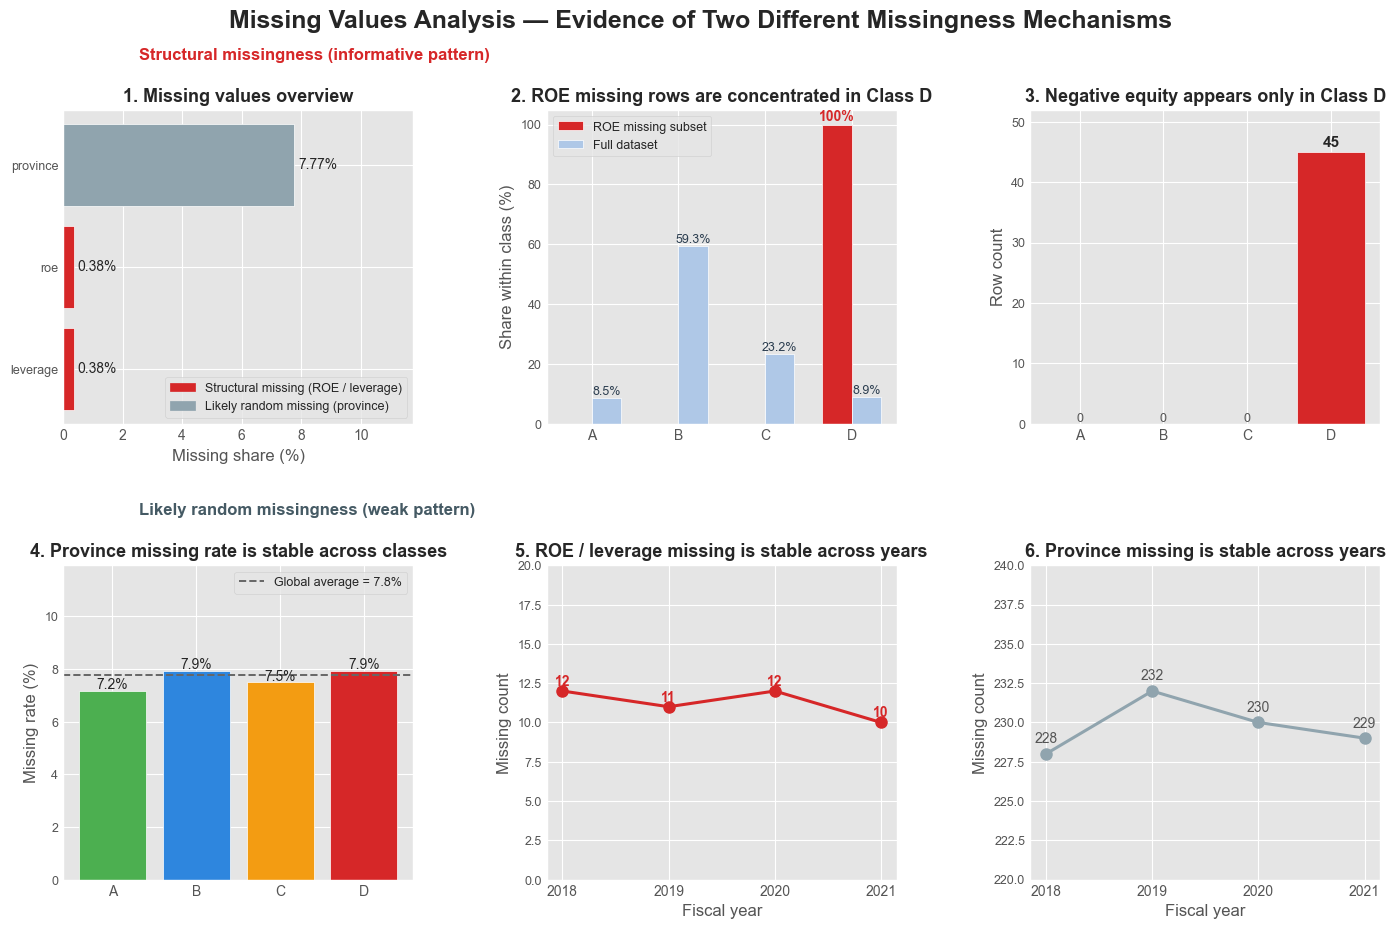

saved: missing_analysis_improved.png


In [228]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Stats
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(train_df) * 100).round(2)
missing_summary = pd.concat([missing, pct], axis=1, keys=["count", "%"])
mask_roe = train_df["roe"].isnull()
neg_equity_mask = train_df.loc[mask_roe, "shareholders_equity"] < 0
class_dist_null = (
    train_df[mask_roe][TARGET]
    .value_counts(normalize=True)
    .reindex(CLASSES, fill_value=0) * 100
)

class_dist_full = (
    train_df[TARGET]
    .value_counts(normalize=True)
    .reindex(CLASSES, fill_value=0) * 100
)

train_df["neg_eq"] = (train_df["shareholders_equity"] < 0).astype(int)
neg_by_class = train_df.groupby(TARGET)["neg_eq"].sum().reindex(CLASSES, fill_value=0)
train_df.drop(columns="neg_eq", inplace=True)

train_df["prov_miss"] = train_df["province"].isnull().astype(int)
prov_rate_by_class = (
    train_df.groupby(TARGET)["prov_miss"]
    .mean()
    .reindex(CLASSES, fill_value=0) * 100
)
train_df.drop(columns="prov_miss", inplace=True)

prov_by_year = train_df.groupby("fiscal_year")["province"].apply(lambda x: x.isnull().sum())
roe_by_year  = train_df.groupby("fiscal_year")["roe"].apply(lambda x: x.isnull().sum())

# Style
plt.style.use("ggplot")
palette = {"A": "#4CAF50", "B": "#2E86DE", "C": "#F39C12", "D": "#D62728"}
class_colors = [palette[c] for c in CLASSES]
structural_red = "#D62728"
random_grey = "#90A4AE"
full_color = "#AFC8E7"
years = [str(y) for y in prov_by_year.index]
global_prov_rate = train_df["province"].isnull().mean() * 100

# Figure layout
fig = plt.figure(figsize=(17, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# 1. Missing overview
feat_labels = missing_summary.index.tolist()
feat_pcts = missing_summary["%"].tolist()
feat_colors = [
    structural_red if f in ["roe", "leverage"] else random_grey
    for f in feat_labels
]

bars = ax1.barh(feat_labels, feat_pcts, color=feat_colors, edgecolor="white")
ax1.invert_yaxis()

for bar, v in zip(bars, feat_pcts):
    ax1.text(v + 0.12, bar.get_y() + bar.get_height()/2, f"{v:.2f}%",
             va="center", fontsize=10)

ax1.set_xlim(0, max(feat_pcts) + 4)
ax1.set_xlabel("Missing share (%)")
ax1.set_title("1. Missing values overview", fontweight="bold", fontsize=13)

legend_handles = [
    Patch(color=structural_red, label="Structural missing (ROE / leverage)"),
    Patch(color=random_grey, label="Likely random missing (province)")
]
ax1.legend(handles=legend_handles, fontsize=9, loc="lower right", frameon=True)

# 2. Class distribution: ROE missing vs full
x = np.arange(len(CLASSES))
w = 0.34

ax2.bar(x - w/2, class_dist_null.values, width=w, color=structural_red,
        edgecolor="white", label="ROE missing subset")
ax2.bar(x + w/2, class_dist_full.values, width=w, color=full_color,
        edgecolor="white", label="Full dataset")

for i, (v1, v2) in enumerate(zip(class_dist_null.values, class_dist_full.values)):
    if v1 > 0:
        ax2.text(i - w/2, v1 + 1.2, f"{v1:.0f}%", ha="center",
                 fontsize=10, fontweight="bold", color=structural_red)
    if v2 > 2:
        ax2.text(i + w/2, v2 + 1.2, f"{v2:.1f}%", ha="center",
                 fontsize=9, color="#2c3e50")

ax2.set_xticks(x)
ax2.set_xticklabels(CLASSES)
ax2.set_ylim(0, 105)
ax2.set_ylabel("Share within class (%)")
ax2.set_title("2. ROE missing rows are concentrated in Class D", fontweight="bold", fontsize=13)
ax2.legend(fontsize=9, frameon=True)

# 3. Negative equity by class
bars3 = ax3.bar(CLASSES, neg_by_class.values, color=class_colors, edgecolor="white")

for i, v in enumerate(neg_by_class.values):
    if v > 0:
        ax3.text(i, v + 0.8, str(v), ha="center", fontsize=11, fontweight="bold")
    else:
        ax3.text(i, 0.4, "0", ha="center", fontsize=9, color="#555")

ax3.set_ylabel("Row count")
ax3.set_title("3. Negative equity appears only in Class D", fontweight="bold", fontsize=13)
ax3.set_ylim(0, max(neg_by_class.values) + 7)

# 4. Province missing rate by class
bars4 = ax4.bar(CLASSES, prov_rate_by_class.values, color=class_colors, edgecolor="white")

for i, v in enumerate(prov_rate_by_class.values):
    ax4.text(i, v + 0.08, f"{v:.1f}%", ha="center", fontsize=10)

ax4.axhline(y=global_prov_rate, color="#666", linestyle="--", linewidth=1.4,
            label=f"Global average = {global_prov_rate:.1f}%")

ax4.set_ylabel("Missing rate (%)")
ax4.set_ylim(0, max(prov_rate_by_class.values) + 4)
ax4.set_title("4. Province missing rate is stable across classes", fontweight="bold", fontsize=13)
ax4.legend(fontsize=9, frameon=True)

# 5. ROE/leverage missing by year
ax5.plot(years, roe_by_year.values, marker="o", color=structural_red,
         linewidth=2.2, markersize=8)

for y, v in zip(years, roe_by_year.values):
    ax5.text(y, v + 0.35, str(v), ha="center", fontsize=10,
             fontweight="bold", color=structural_red)

ax5.set_ylabel("Missing count")
ax5.set_xlabel("Fiscal year")
ax5.set_ylim(0, max(roe_by_year.values) + 8)
ax5.set_title("5. ROE / leverage missing is stable across years", fontweight="bold", fontsize=13)

# 6. Province missing by year
ax6.plot(years, prov_by_year.values, marker="o", color=random_grey,
         linewidth=2.2, markersize=8)

for y, v in zip(years, prov_by_year.values):
    ax6.text(y, v + 0.7, str(v), ha="center", fontsize=10, color="#555")

ax6.set_ylabel("Missing count")
ax6.set_xlabel("Fiscal year")
ax6.set_ylim(min(prov_by_year.values) - 8, max(prov_by_year.values) + 8)
ax6.set_title("6. Province missing is stable across years", fontweight="bold", fontsize=13)

# Global title and section headers
fig.suptitle(
    "Missing Values Analysis — Evidence of Two Different Missingness Mechanisms",
    fontsize=18, fontweight="bold", y=0.98
)

fig.text(0.17, 0.93, "Structural missingness (informative pattern)",
         fontsize=12, fontweight="bold", color=structural_red)
fig.text(0.17, 0.475, "Likely random missingness (weak pattern)",
         fontsize=12, fontweight="bold", color="#455A64")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("missing_analysis_improved.png", dpi=150, bbox_inches="tight")
plt.show()

print("saved: missing_analysis_improved.png")


## Section 3 — Missing Values: Findings

### 3.1 Overview

Only 3 columns have missing values:

| Column | Missing | % | Type |
|--------|---------|---|------|
| `province` | 919 | 7.77% | Random (MCAR) |
| `roe` | 45 | 0.38% | Structural |
| `leverage` | 45 | 0.38% | Structural |

The dataset is **exceptionally clean** — no balance sheet or income statement
items are missing.

---

### 3.2 ROE & Leverage — Structural Missingness (100% signal for class D)

All 45 null `roe` and `leverage` rows belong to the **exact same observations**
and all have **negative shareholders equity**.

When equity is negative:
- `roe = net_profit / equity` → mathematically valid but financially meaningless
- `leverage = total_debt / equity` → negative leverage is uninterpretable

The dataset correctly marks these as `NaN` rather than showing a misleading value.

**Critical finding: 100% of rows where ROE is null are class D.**

This means null `roe`/`leverage` is not a data quality issue —
it is the **strongest possible signal of distress** in the entire dataset.

→ **Do NOT impute these with median.** Instead:
1. Create `roe_is_null` binary feature (= 1 when equity is negative)
2. Impute the raw value with an **extreme negative sentinel** (e.g. `-99`)
   to preserve the distress signal for tree-based models
3. For linear models, impute with a value well below the 1st percentile

---

### 3.3 Negative Equity Deep Dive

Negative equity is **exclusive to class D** — zero cases in A, B, or C.
However it only covers **4.3% of all D rows** (45 / 1,058).

| Finding | Implication |
|---|---|
| Negative equity never appears in A/B/C | `roe_is_null` is a **perfect precision** signal — when it fires, it is always D |
| Only 4.3% of D rows have negative equity | `roe_is_null` has **very low recall** — catches only a small fraction of distressed companies |

This means negative equity is a **late-stage distress indicator** — the company
is already deep in trouble. The model must detect D much earlier using
deterioration signals from other features (leverage trend, ROI decline,
liquidity squeeze) before equity turns negative.

→ `roe_is_null` is a **high-precision, low-recall** feature. Keep it — it will
likely become a top split in tree-based models for class D. The bulk of D
detection must come from financial ratio trends.

---

### 3.4 Province — Missing Completely at Random (MCAR)

Province missingness rate is **uniform across all classes** (~7.2–7.9%):

| Class | Province missing % |
|-------|--------------------|
| A | 7.2% |
| B | 7.9% |
| C | 7.5% |
| D | 7.9% |

No correlation with class, sector, or fiscal year (stable ~229 missing per year).
This is **Missing Completely at Random (MCAR)** — likely companies that registered
without a province code in the source database.

→ **Impute with a new category `"UNKNOWN"`** — do not drop rows or use
mode imputation, as province is a categorical with 107 levels and the
missing pattern carries no financial signal.

---

### 3.5 Missingness is Stable Across Years

No year concentration — ~11–12 null `roe`/`leverage` and ~229 null `province`
per year consistently. No COVID-related reporting gaps detected.

---

### Preprocessing Decisions from Section 3

| Column | Treatment | Rationale |
|--------|-----------|-----------|
| `roe`, `leverage` | Add `roe_is_null` binary flag → impute with sentinel `-99` | Perfect D signal, must preserve |
| `province` | Impute with `"UNKNOWN"` category | MCAR, no financial signal |
| All other columns | No imputation needed | Dataset is complete |

### 4. Descriptive Statistics
- Summary stats for all numerical columns
- Log-scale histograms for balance sheet items (heavy right skew expected)
- Check impossible values: negative revenue, `debt_to_assets > 1`


In [229]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import f_oneway, kruskal

# Hard distress thresholds
train_df["is_terminal_distress"] = (
    (train_df["debt_to_assets"] > 1) |
    (train_df["leverage"] > 50)      |
    (train_df["shareholders_equity"] < 0)
).astype(int)

terminal = train_df[train_df["is_terminal_distress"] == 1]
print("=== HARD DISTRESS THRESHOLDS ===")
print(f"Total terminal distress rows: {len(terminal)}")
print(f"Class distribution:\n{terminal[TARGET].value_counts()}")
print(f"\nOverlap check:")
print(f"  equity<0:           {(train_df['shareholders_equity'] < 0).sum()}")
print(f"  debt_to_assets>1:   {(train_df['debt_to_assets'] > 1).sum()}")
print(f"  leverage>50:        {(train_df['leverage'] > 50).sum()}")
print(f"  All same rows:      {train_df[train_df['shareholders_equity']<0].index.equals(train_df[train_df['debt_to_assets']>1].index)}")

# Ratio distributions by class (ANOVA + Kruskal-Wallis)
RATIO_COLS = ["roe", "roi", "profit_margin", "leverage",
              "debt_to_assets", "current_ratio", "quick_ratio"]

print("\n=== CLASS SEPARABILITY — RATIO FEATURES ===")
print(f"{'Feature':<20} {'A_med':>7} {'B_med':>7} {'C_med':>7} {'D_med':>7} {'KW_p':>10} {'Signal'}")
print("-" * 75)

kw_results = {}
for col in RATIO_COLS:
    groups = [train_df[train_df[TARGET] == c][col].dropna() for c in CLASSES]
    medians = [g.median() for g in groups]
    _, p = kruskal(*groups)
    kw_results[col] = p
    signal = "★★★" if p < 0.001 else ("★★" if p < 0.01 else ("★" if p < 0.05 else "—"))
    print(f"{col:<20} {medians[0]:>7.3f} {medians[1]:>7.3f} {medians[2]:>7.3f} {medians[3]:>7.3f} {p:>10.2e}  {signal}")

# Operating cost ratio by class
train_df["op_cost_ratio"] = train_df["production_costs"] / train_df["production_value"]
print("\n=== OPERATING COST RATIO BY CLASS ===")
print(train_df.groupby(TARGET)["op_cost_ratio"].median().round(4))
_, p_op = kruskal(*[train_df[train_df[TARGET]==c]["op_cost_ratio"].dropna() for c in CLASSES])
print(f"Kruskal-Wallis p={p_op:.2e}")

# Winsorization boundaries
print("\n=== WINSORIZATION BOUNDARIES (1st–99th percentile) ===")
for col in ["roe", "leverage"]:
    lo, hi = train_df[col].quantile([0.01, 0.99])
    n_clipped = ((train_df[col] < lo) | (train_df[col] > hi)).sum()
    print(f"{col:<12}  [{lo:.3f}, {hi:.3f}]  rows affected: {n_clipped}")

# Log-normality check for balance sheet vars
BS_COLS = ["total_assets", "production_value", "total_debt",
           "shareholders_equity", "current_assets", "total_fixed_assets"]

print("\n=== SKEWNESS: RAW vs LOG ===")
print(f"{'Feature':<25} {'raw_skew':>10} {'log_skew':>10} {'log_better'}")
print("-" * 55)
for col in BS_COLS:
    vals = train_df[col].dropna()
    pos_vals = vals[vals > 0]
    raw_skew = vals.skew()
    log_skew = np.log(pos_vals).skew()
    better = "✓" if abs(log_skew) < abs(raw_skew) else "✗"
    print(f"{col:<25} {raw_skew:>10.2f} {log_skew:>10.2f}   {better}")

=== HARD DISTRESS THRESHOLDS ===
Total terminal distress rows: 50
Class distribution:
financial_health_class
D    50
Name: count, dtype: int64

Overlap check:
  equity<0:           45
  debt_to_assets>1:   45
  leverage>50:        5
  All same rows:      True

=== CLASS SEPARABILITY — RATIO FEATURES ===
Feature                A_med   B_med   C_med   D_med       KW_p Signal
---------------------------------------------------------------------------
roe                    0.270   0.236   0.230  -0.105   0.00e+00  ★★★
roi                    0.158   0.116   0.088   0.007   0.00e+00  ★★★
profit_margin          0.087   0.067   0.046  -0.015   0.00e+00  ★★★
leverage               0.901   1.419   2.692   5.517   0.00e+00  ★★★
debt_to_assets         0.474   0.587   0.729   0.851   0.00e+00  ★★★
current_ratio          2.482   1.937   1.461   1.364   0.00e+00  ★★★
quick_ratio            1.489   1.162   0.876   0.818   0.00e+00  ★★★

=== OPERATING COST RATIO BY CLASS ===
financial_health_class
A  

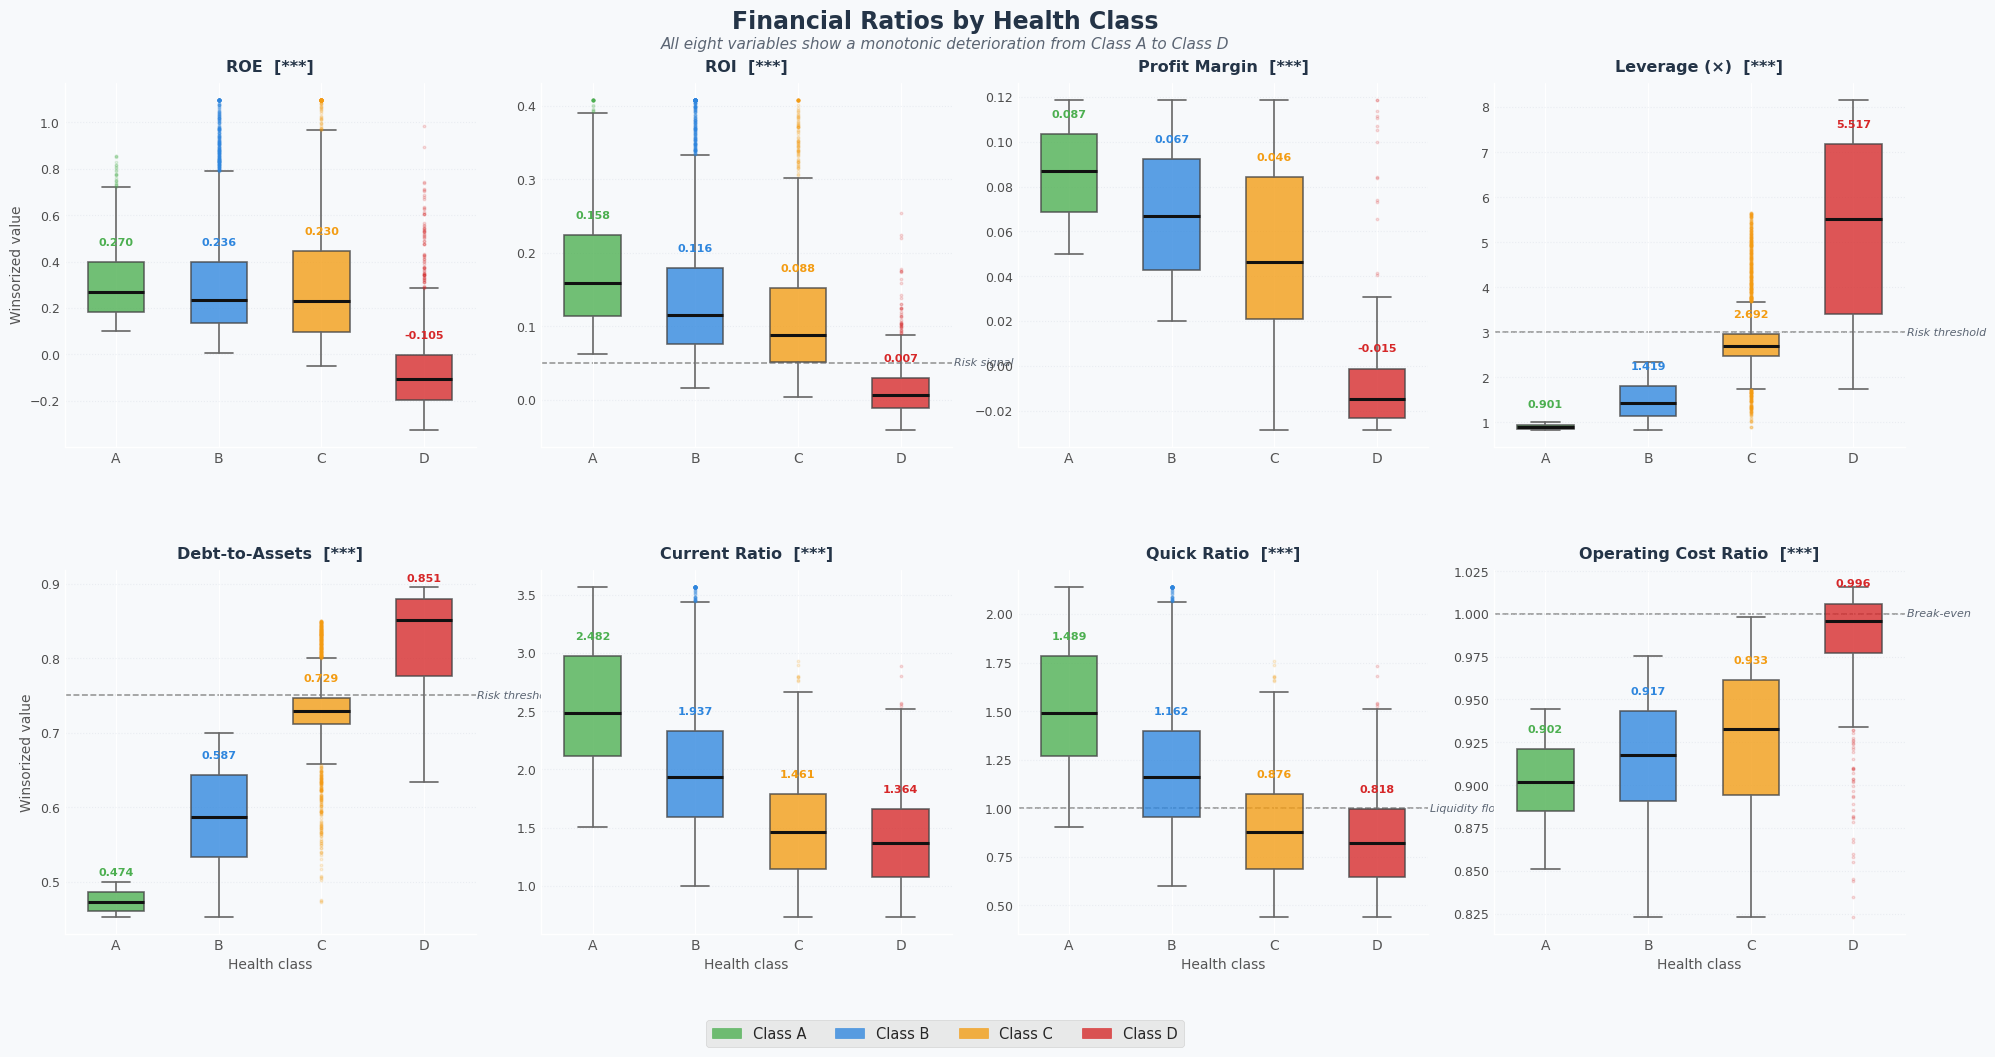

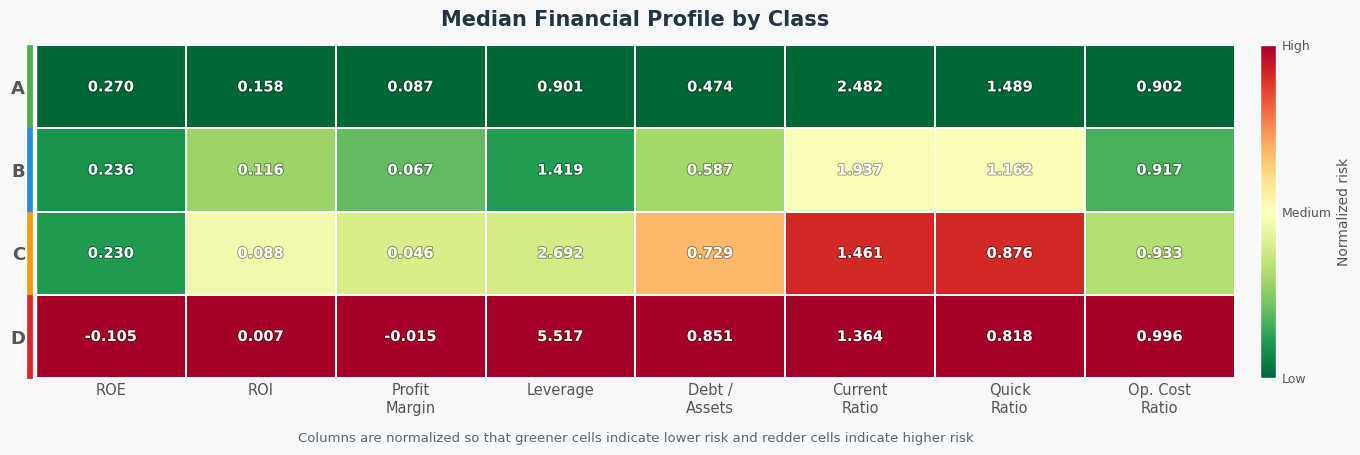

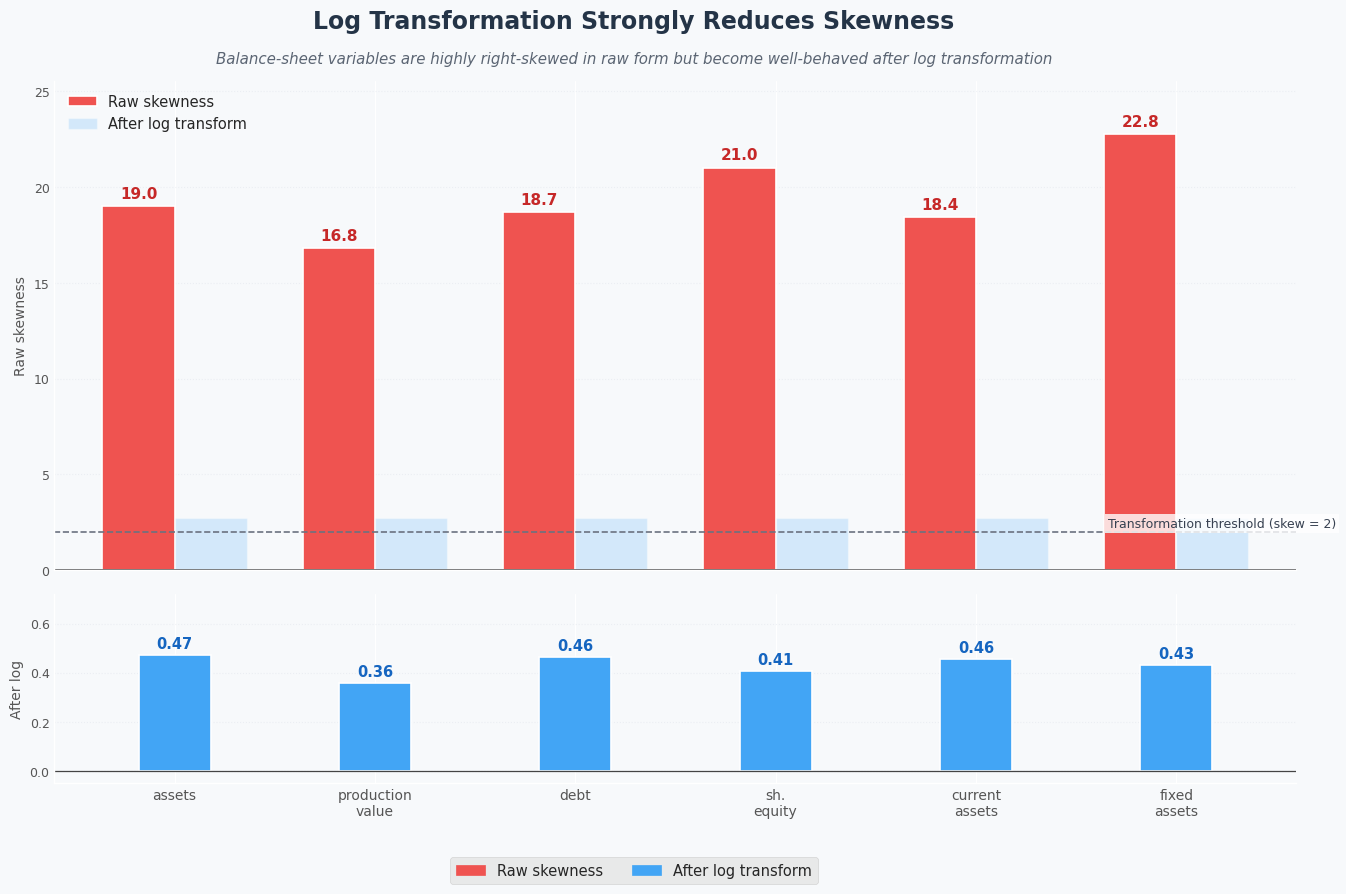

Saved: ratio_boxplots_improved.png | ordinal_gradient_improved.png | log_transform_improved.png


In [259]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib.colors import Normalize
from pathlib import Path
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Global style
rcParams["font.family"] = "DejaVu Sans"
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.titleweight"] = "bold"
rcParams["axes.labelsize"] = 10
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 9

BG = "#f7f9fb"
GRID = "#d9dee7"
TEXT = "#243447"
SUBTLE = "#5b6573"

# Prep
train_df["op_cost_ratio"] = train_df["production_costs"] / train_df["production_value"]
ALL_COLS = RATIO_COLS + ["op_cost_ratio"]
kw_results["op_cost_ratio"] = p_op

plot_df = train_df.copy()
for col in ALL_COLS:
    lo, hi = plot_df[col].quantile([0.01, 0.99])
    plot_df[col] = plot_df[col].clip(lo, hi)

YLABELS = {
    "roe": "ROE",
    "roi": "ROI",
    "profit_margin": "Profit Margin",
    "leverage": "Leverage (×)",
    "debt_to_assets": "Debt-to-Assets",
    "current_ratio": "Current Ratio",
    "quick_ratio": "Quick Ratio",
    "op_cost_ratio": "Operating Cost Ratio",
}

THRESHOLDS = {
    "leverage": (3.0, "Risk threshold"),
    "debt_to_assets": (0.75, "Risk threshold"),
    "quick_ratio": (1.0, "Liquidity floor"),
    "op_cost_ratio": (1.0, "Break-even"),
    "roi": (0.05, "Risk signal"),
}

COL_LABELS = {
    "roe": "ROE",
    "roi": "ROI",
    "profit_margin": "Profit\nMargin",
    "leverage": "Leverage",
    "debt_to_assets": "Debt /\nAssets",
    "current_ratio": "Current\nRatio",
    "quick_ratio": "Quick\nRatio",
    "op_cost_ratio": "Op. Cost\nRatio",
}

FLIP_COLS = ["roe", "roi", "profit_margin", "current_ratio", "quick_ratio"]

short_lbls = [
    c.replace("total_", "")
     .replace("shareholders_", "sh.\n")
     .replace("_", "\n")
    for c in BS_COLS
]

# FIGURE 1 — BOXPLOTS DASHBOARD
fig, axes = plt.subplots(2, 4, figsize=(20, 10.5))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for i, col in enumerate(ALL_COLS):
    ax = axes[i]
    ax.set_facecolor(BG)

    data_by_class = [plot_df.loc[plot_df[TARGET] == c, col].dropna() for c in CLASSES]
    medians = [d.median() for d in data_by_class]

    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color="#111111", linewidth=2.2),
        whiskerprops=dict(linewidth=1.2, color="#666666"),
        capprops=dict(linewidth=1.2, color="#666666"),
        flierprops=dict(marker="o", markersize=1.8, alpha=0.15, linestyle="none"),
        boxprops=dict(linewidth=1.2, edgecolor="#444444"),
    )

    for patch, cls in zip(bp["boxes"], CLASSES):
        patch.set_facecolor(palette[cls])
        patch.set_alpha(0.78)

    for flier, cls in zip(bp["fliers"], CLASSES):
        flier.set_markerfacecolor(palette[cls])
        flier.set_markeredgecolor(palette[cls])

    # Thresholds
    if col in THRESHOLDS:
        val, label = THRESHOLDS[col]
        ax.axhline(val, color="#7a7a7a", linestyle="--", linewidth=1.15, alpha=0.8, zorder=0)
        ax.text(
            4.45, val, f"  {label}",
            va="center", ha="left",
            fontsize=8, color=SUBTLE, style="italic"
        )

    # Median labels
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.08
    for j, (d, cls) in enumerate(zip(data_by_class, CLASSES), start=1):
        q3 = np.percentile(d, 75)
        ax.text(
        j,
        q3 + (y_max - y_min) * 0.04,
        f"{d.median():.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color=palette[cls]
    )

    p = kw_results[col]
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else "*")

    ax.set_title(f"{YLABELS[col]}  [{stars}]", fontsize=11.5, pad=8, color=TEXT)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(CLASSES)
    ax.grid(axis="y", linestyle=":", alpha=0.45, color=GRID)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", colors="#4d4d4d")

    # y-label
    if i % 4 == 0:
        ax.set_ylabel("Winsorized value")
    else:
        ax.set_ylabel("")

    # x-label
    if i >= 4:
        ax.set_xlabel("Health class")
    else:
        ax.set_xlabel("")

legend_patches = [
    mpatches.Patch(color=palette[c], alpha=0.78, label=f"Class {c}")
    for c in CLASSES
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=4,
    fontsize=10.5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.005)
)

fig.suptitle(
    "Financial Ratios by Health Class",
    fontsize=17,
    fontweight="bold",
    y=0.99,
    color=TEXT
)
fig.text(
    0.5, 0.953,
    "All eight variables show a monotonic deterioration from Class A to Class D",
    ha="center", fontsize=11, color=SUBTLE, style="italic"
)

plt.subplots_adjust(top=0.92, bottom=0.11, left=0.06, right=0.98, hspace=0.34, wspace=0.16)
plt.savefig(FIG_DIR / "ratio_boxplots_improved.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# FIGURE 2 — HEATMAP OF MEDIANS
median_table = pd.DataFrame(
    {
        col: [plot_df.loc[plot_df[TARGET] == c, col].median() for c in CLASSES]
        for col in ALL_COLS
    },
    index=CLASSES
)

normed = median_table.copy()
for col in normed.columns:
    lo, hi = normed[col].min(), normed[col].max()
    normed[col] = (normed[col] - lo) / (hi - lo + 1e-9)

for col in FLIP_COLS:
    normed[col] = 1 - normed[col]

fig, ax = plt.subplots(figsize=(14.5, 5.2))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# coordinate grid for pcolormesh
X = np.arange(len(ALL_COLS) + 1)
Y = np.arange(len(CLASSES) + 1)

mesh = ax.pcolormesh(
    X,
    Y,
    normed.values,
    cmap=plt.cm.RdYlGn_r,
    vmin=0,
    vmax=1,
    edgecolors="white",
    linewidth=1.2,
    shading="flat"
)

# put first row at the top
ax.invert_yaxis()

# values INSIDE the rectangles only
for i, cls in enumerate(CLASSES):
    for j, col in enumerate(ALL_COLS):
        raw = median_table.loc[cls, col]
        t = ax.text(
            j + 0.5, i + 0.5, f"{raw:.3f}",
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
            color="white"
        )
        t.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black", alpha=0.35)])

# single class strip on the left
for i, cls in enumerate(CLASSES):
    ax.add_patch(
        plt.Rectangle(
            (-0.06, i), 0.035, 1,
            color=palette[cls],
            transform=ax.transData,
            clip_on=False,
            zorder=5
        )
    )

# ticks centered in each cell
ax.set_xticks(np.arange(len(ALL_COLS)) + 0.5)
ax.set_xticklabels([COL_LABELS[c] for c in ALL_COLS], fontsize=10.5)

ax.set_yticks(np.arange(len(CLASSES)) + 0.5)
ax.set_yticklabels(CLASSES, fontsize=13, fontweight="bold")
ax.tick_params(axis="y", pad=8)

ax.tick_params(length=0)

cbar = plt.colorbar(mesh, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Normalized risk", fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Low", "Medium", "High"])

ax.set_title(
    "Median Financial Profile by Class",
    fontsize=15,
    fontweight="bold",
    pad=14,
    color=TEXT
)

ax.set_xlabel(
    "Columns are normalized so that greener cells indicate lower risk and redder cells indicate higher risk",
    fontsize=9.5,
    color=SUBTLE,
    labelpad=12
)

plt.subplots_adjust(top=0.86, bottom=0.22, left=0.09, right=0.96)
plt.savefig(FIG_DIR / "ordinal_gradient_improved.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


# FIGURE 3 — LOG TRANSFORM BEFORE / AFTER
raw_skews = []
log_skews = []

for col in BS_COLS:
    vals = train_df[col].dropna()
    raw_skews.append(vals.skew())
    log_vals = vals[vals > 0]
    log_skews.append(np.log(log_vals).skew())

x = np.arange(len(BS_COLS))
w = 0.36

fig, (ax_main, ax_zoom) = plt.subplots(
    2, 1,
    figsize=(13.8, 9),
    gridspec_kw={"height_ratios": [3.1, 1.2], "hspace": 0.07}
)
fig.patch.set_facecolor(BG)

for ax in (ax_main, ax_zoom):
    ax.set_facecolor(BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Raw skewness
bars_raw = ax_main.bar(
    x - w/2, raw_skews, width=w,
    color="#ef5350", edgecolor="white", linewidth=1.2,
    label="Raw skewness"
)

# faint placeholder bars for alignment
ax_main.bar(
    x + w/2, [max(raw_skews) * 0.12] * len(BS_COLS), width=w,
    color="#90caf9", edgecolor="white", linewidth=1.0, alpha=0.35,
    label="After log transform"
)

for bar, v in zip(bars_raw, raw_skews):
    ax_main.text(
        bar.get_x() + bar.get_width() / 2, v + 0.25, f"{v:.1f}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color="#c62828"
    )

ax_main.axhline(2, color="#6b7280", linestyle="--", linewidth=1.2)
ax_main.text(
    len(BS_COLS) - 0.2, 2.1,
    "Transformation threshold (skew = 2)",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#374151",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2)
)

ax_main.set_ylabel("Raw skewness")
ax_main.set_ylim(0, max(raw_skews) * 1.12)
ax_main.set_xlim(-0.6, len(BS_COLS) - 0.4)
ax_main.axhline(0, color="#555555", linewidth=1.3)
ax_main.set_xticks(x)
ax_main.set_xticklabels([""] * len(BS_COLS))
ax_main.grid(axis="y", linestyle=":", alpha=0.4, color=GRID)
ax_main.legend(fontsize=10.5, loc="upper left", frameon=False)

# log skewness
bars_log = ax_zoom.bar(
    x, log_skews, width=w,
    color="#42a5f5", edgecolor="white", linewidth=1.2
)

for bar, v in zip(bars_log, log_skews):
    ax_zoom.text(
        bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.2f}",
        ha="center", va="bottom",
        fontsize=10.5, fontweight="bold", color="#1565c0"
    )

ax_zoom.axhline(0, color="#444444", linewidth=0.9)
ax_zoom.set_ylabel("After log")
ax_zoom.set_ylim(-0.05, 0.72)
ax_zoom.set_xlim(-0.6, len(BS_COLS) - 0.4)
ax_zoom.set_xticks(x)
ax_zoom.set_xticklabels(short_lbls, fontsize=10)
ax_zoom.grid(axis="y", linestyle=":", alpha=0.4, color=GRID)


fig.suptitle(
    "Log Transformation Strongly Reduces Skewness",
    fontsize=17,
    fontweight="bold",
    y=0.98,
    color=TEXT
)
fig.text(
    0.5, 0.92,
    "Balance-sheet variables are highly right-skewed in raw form but become well-behaved after log transformation",
    ha="center", fontsize=10.8, color=SUBTLE, style="italic"
)

legend_handles = [
    mpatches.Patch(color="#ef5350", label="Raw skewness"),
    mpatches.Patch(color="#42a5f5", label="After log transform")
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    fontsize=10.5,
    frameon=True,
    bbox_to_anchor=(0.5, 0.0),
    bbox_transform=fig.transFigure
)

plt.subplots_adjust(top=0.90, bottom=0.12, left=0.08, right=0.98)
plt.savefig(FIG_DIR / "log_transform_improved.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Cleanup
train_df.drop(columns=["is_terminal_distress", "op_cost_ratio"], inplace=True, errors="ignore")

print("Saved: ratio_boxplots_improved.png | ordinal_gradient_improved.png | log_transform_improved.png")



**Visual 1 — Boxplots (Winsorized 1–99%)**
Each box shows IQR (25th–75th percentile), the black line is the median,
whiskers extend to 1.5×IQR. Outliers are shown as faint dots.
Dashed lines mark domain-relevant risk thresholds (e.g. leverage > 3.0,
quick ratio < 1.0). All values winsorized for display only — `train_df`
is not modified.

**Visual 2 — Ordinal Gradient Heatmap**
Each cell shows the raw median value for that class/feature combination.
Color encodes normalized risk: red = high risk, green = low risk.
Columns are normalized independently (0–1 per column), so color is
comparable within a column, not across columns.
Profitability features (ROE, ROI, Profit Margin, Current Ratio,
Quick Ratio) are flipped so that red always means "worse health."

**Visual 3 — Log Transform (Broken Axis)**
Top panel: raw skewness (17–23). Bottom panel: skewness after
log transform (0.36–0.47). Axis is intentionally broken — the two
panels use different y-scales to make the log values readable.
Dashed line at skew=2 marks the conventional transformation threshold.


# §6 Feature Separability by Class

In [231]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

CLASS_ORDER = ["A", "B", "C", "D"]
PALETTE     = {"A": "#2ecc71", "B": "#3498db", "C": "#f39c12", "D": "#e74c3c"}

df = train_df.copy()
df["financial_health_class"] = pd.Categorical(
    df["financial_health_class"], categories=CLASS_ORDER, ordered=True
)

In [232]:
FEATURES = {
    "roe":            (-5,   5),
    "roi":            (-1,   1),
    "current_ratio":  ( 0,   5),
    "debt_to_assets": ( 0,   2),
    "profit_margin":  (-1,   1),
    "leverage":       (-5,  20),
}

In [233]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (feat, (lo, hi)) in zip(axes, FEATURES.items()):
    plot_df = df[["financial_health_class", feat]].copy()
    plot_df[feat] = plot_df[feat].clip(lo, hi)

    sns.violinplot(
        data=plot_df,
        x="financial_health_class",
        y=feat,
        order=CLASS_ORDER,
        palette=PALETTE,
        inner="quartile",
        linewidth=0.8,
        ax=ax,
    )
    ax.set_title(feat, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=9)

fig.suptitle(
    "§6 — Feature Separability by Class\n(violin plots, clipped for display only)",
    fontsize=13, fontweight="bold", y=1.01
)
fig.tight_layout()
out = FIG_DIR / "eda_s6_separability.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Figure saved → {out}")

/var/folders/10/5pr64d916tn68kkg36yw_6080000gn/T/ipykernel_2032/2882241286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/10/5pr64d916tn68kkg36yw_6080000gn/T/ipykernel_2032/2882241286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/10/5pr64d916tn68kkg36yw_6080000gn/T/ipykernel_2032/2882241286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/10/5pr64d916tn68kkg36yw_6080000gn/T/ipykernel_2032/2882241286.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

Figure saved → figures/eda_s6_separability.png


In [234]:
print("\nMedian by class:")
med = (
    df.groupby("financial_health_class")[list(FEATURES)]
    .median()
    .round(3)
)
print(med.to_string())


Median by class:
                          roe    roi  current_ratio  debt_to_assets  profit_margin  leverage
financial_health_class                                                                      
A                       0.270  0.158          2.482           0.474          0.087     0.901
B                       0.236  0.116          1.937           0.587          0.067     1.420
C                       0.230  0.088          1.461           0.729          0.046     2.692
D                      -0.105  0.007          1.364           0.851         -0.015     5.517


In [235]:
print("\nMonotonicity check (A→B→C→D):")
for feat in FEATURES:
    medians = med[feat].values  # order: A, B, C, D
    is_monotone_down = all(medians[i] >= medians[i+1] for i in range(3))
    is_monotone_up   = all(medians[i] <= medians[i+1] for i in range(3))
    direction = (
        "↓ monotone decreasing" if is_monotone_down else
        "↑ monotone increasing" if is_monotone_up   else
        "~ non-monotone"
    )
    print(f"  {feat:20s} {direction}  {list(medians.round(3))}")


Monotonicity check (A→B→C→D):
  roe                  ↓ monotone decreasing  [np.float64(0.27), np.float64(0.236), np.float64(0.23), np.float64(-0.105)]
  roi                  ↓ monotone decreasing  [np.float64(0.158), np.float64(0.116), np.float64(0.088), np.float64(0.007)]
  current_ratio        ↓ monotone decreasing  [np.float64(2.482), np.float64(1.937), np.float64(1.461), np.float64(1.364)]
  debt_to_assets       ↑ monotone increasing  [np.float64(0.474), np.float64(0.587), np.float64(0.729), np.float64(0.851)]
  profit_margin        ↓ monotone decreasing  [np.float64(0.087), np.float64(0.067), np.float64(0.046), np.float64(-0.015)]
  leverage             ↑ monotone increasing  [np.float64(0.901), np.float64(1.42), np.float64(2.692), np.float64(5.517)]


# §7 Correlation Analysis

In [236]:
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

NUM_COLS = [
    "total_fixed_assets", "current_assets", "shareholders_equity",
    "total_debt", "short_term_debt", "long_term_debt",
    "production_value", "production_costs", "operating_income",
    "net_profit_loss",
    "roe", "roi", "leverage", "current_ratio", "quick_ratio",
    "debt_to_assets", "profit_margin",
    "years_in_business",
]
NUM_COLS = [c for c in NUM_COLS if c in train_df.columns]

LABELS = {
    "total_fixed_assets": "Fixed assets",
    "current_assets": "Current assets",
    "shareholders_equity": "Equity",
    "total_debt": "Total debt",
    "short_term_debt": "Short-term debt",
    "long_term_debt": "Long-term debt",
    "production_value": "Production value",
    "production_costs": "Production costs",
    "operating_income": "Operating income",
    "net_profit_loss": "Net profit/loss",
    "roe": "ROE",
    "roi": "ROI",
    "leverage": "Leverage",
    "current_ratio": "Current ratio",
    "quick_ratio": "Quick ratio",
    "debt_to_assets": "Debt / assets",
    "profit_margin": "Profit margin",
    "years_in_business": "Years in business",
}

corr = train_df[NUM_COLS].corr(method="spearman")

# mask upper triangle only
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)


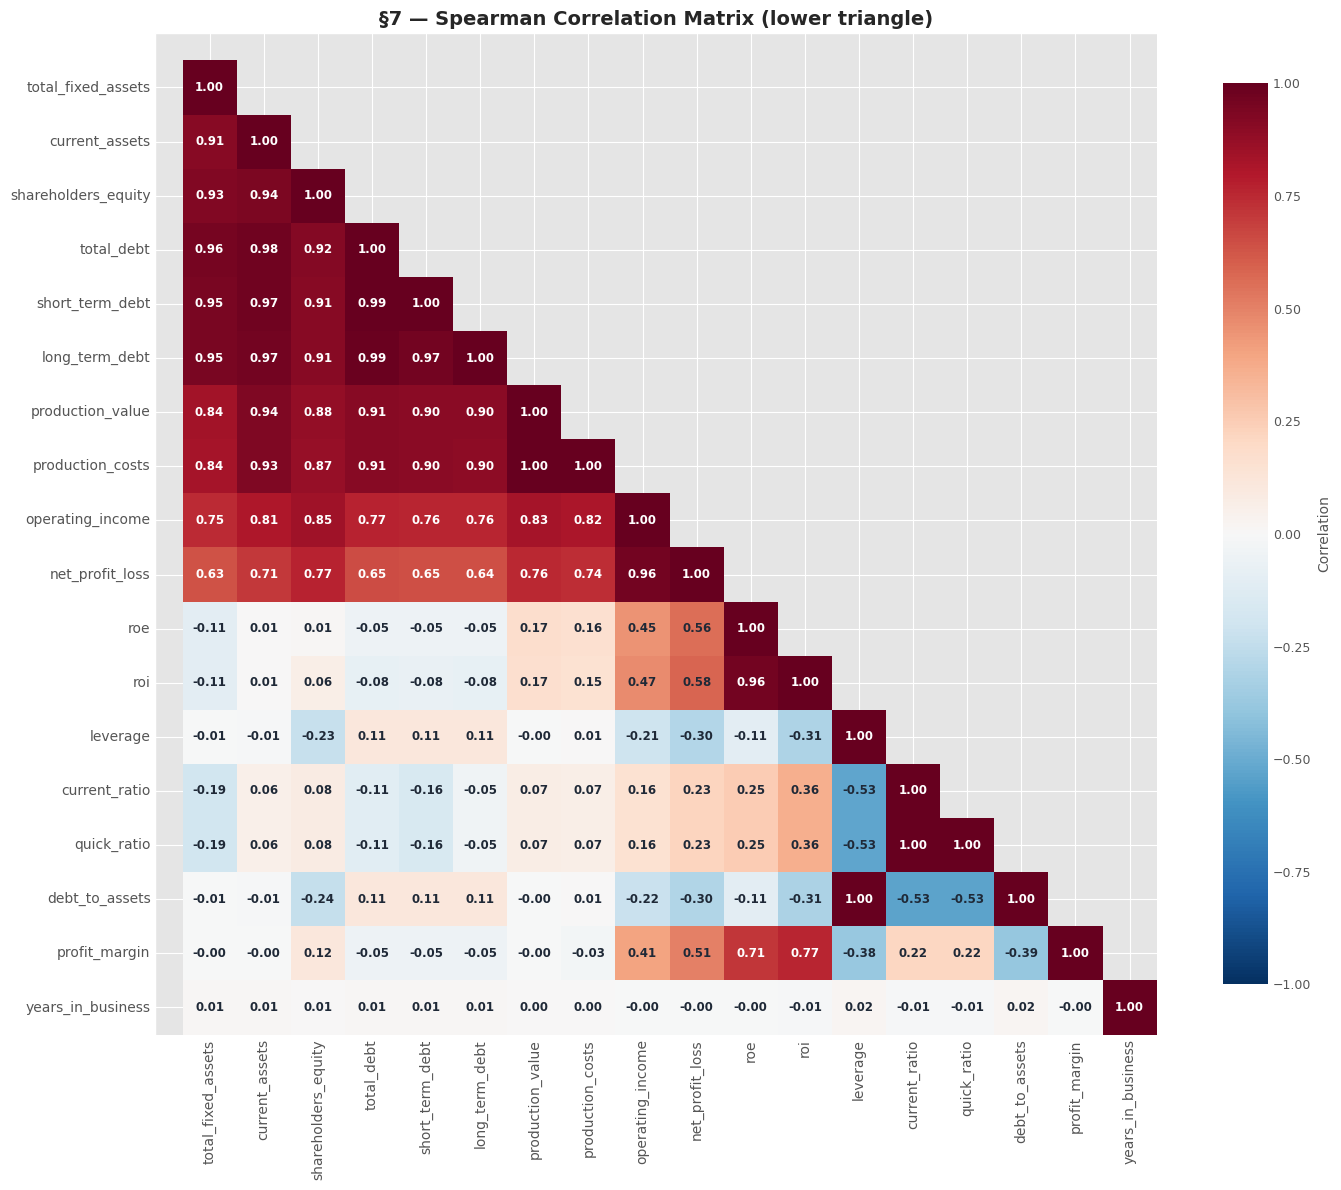

In [237]:
fig, ax = plt.subplots(figsize=(15, 12))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0,
    square=True,
    cbar_kws={"shrink": 0.90},
    annot_kws={"size": 8.5, "weight": "bold"},
    ax=ax
)

# borders
ax.set_xticks(np.arange(len(corr) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(corr) + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# tick labels
ax.set_xticklabels(corr.columns, rotation=90, fontsize=10)
ax.set_yticklabels(corr.index, rotation=0, fontsize=10)

# title
ax.set_title(
    "§7 — Spearman Correlation Matrix (lower triangle)",
    fontsize=14,
    fontweight="bold"
)

# annotation
for text in ax.texts:
    s = text.get_text().strip()
    if not s:
        continue
    try:
        val = float(s)
    except ValueError:
        continue
    text.set_color("white" if abs(val) >= 0.60 else "#1f2937")

# colorbar
cbar = ax.collections[0].colorbar
cbar.set_label("Correlation", fontsize=10)
cbar.ax.tick_params(labelsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "eda_s7_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [238]:
HIGH_THR = 0.85
pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) >= HIGH_THR:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

pairs.sort(key=lambda x: -abs(x[2]))

print(f"High-correlation pairs (|r| ≥ {HIGH_THR}):")
if pairs:
    for a, b, r in pairs:
        print(f"  {a:30s} ↔  {b:30s}  r={r:+.3f}")
else:
    print("  None found.")

High-correlation pairs (|r| ≥ 0.85):
  production_costs               ↔  production_value                r=+1.000
  quick_ratio                    ↔  current_ratio                   r=+1.000
  debt_to_assets                 ↔  leverage                        r=+1.000
  short_term_debt                ↔  total_debt                      r=+0.993
  long_term_debt                 ↔  total_debt                      r=+0.989
  total_debt                     ↔  current_assets                  r=+0.976
  short_term_debt                ↔  current_assets                  r=+0.969
  long_term_debt                 ↔  short_term_debt                 r=+0.966
  long_term_debt                 ↔  current_assets                  r=+0.965
  net_profit_loss                ↔  operating_income                r=+0.964
  roi                            ↔  roe                             r=+0.962
  total_debt                     ↔  total_fixed_assets              r=+0.960
  short_term_debt                ↔  tot

§8 Panel Completeness

In [239]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

CLASS_ORDER = ["A", "B", "C", "D"]
PALETTE     = {"A": "#2ecc71", "B": "#3498db", "C": "#f39c12", "D": "#e74c3c"}

df = train_df.copy()

In [240]:
years_per = df.groupby("company_id")["fiscal_year"].nunique().rename("n_years")
vc        = years_per.value_counts().sort_index()
pct_full  = (years_per == 4).mean() * 100

print("Years in panel distribution:")
for yr, cnt in vc.items():
    print(f"  {yr} year(s): {cnt:>5,} companies  ({cnt/len(years_per)*100:.1f}%)")
print(f"\nCompanies with full 4-year history: {pct_full:.1f}%")

Years in panel distribution:
  1 year(s):    20 companies  (0.7%)
  2 year(s):    24 companies  (0.8%)
  3 year(s):    60 companies  (2.0%)
  4 year(s): 2,895 companies  (96.5%)

Companies with full 4-year history: 96.5%


In [241]:
years_per = df.groupby("company_id")["fiscal_year"].nunique().rename("n_years")
vc        = years_per.value_counts().sort_index()
pct_full  = (years_per == 4).mean() * 100

print("Years in panel distribution:")
for yr, cnt in vc.items():
    print(f"  {yr} year(s): {cnt:>5,} companies  ({cnt/len(years_per)*100:.1f}%)")
print(f"\nCompanies with full 4-year history: {pct_full:.1f}%")

Years in panel distribution:
  1 year(s):    20 companies  (0.7%)
  2 year(s):    24 companies  (0.8%)
  3 year(s):    60 companies  (2.0%)
  4 year(s): 2,895 companies  (96.5%)

Companies with full 4-year history: 96.5%


In [242]:
# every company's first observed year will have NaN lag → 1 row per company
total_rows     = len(df)
nan_lag_rows   = df.groupby("company_id")["fiscal_year"].min().shape[0]  # 1 per company
nan_lag_pct    = nan_lag_rows / total_rows * 100
print(f"\nEstimated NaN rows for lag features: {nan_lag_rows:,} / {total_rows:,}  ({nan_lag_pct:.1f}%)")


Estimated NaN rows for lag features: 2,999 / 11,828  (25.4%)


In [243]:
incomplete = years_per[years_per < 4].index
inc_df     = df[df["company_id"].isin(incomplete)]

print(f"\nClass distribution — incomplete companies (<4 years):")
print(inc_df["financial_health_class"].value_counts(normalize=True).mul(100).round(1).to_string())
print(f"\nClass distribution — full dataset:")
print(df["financial_health_class"].value_counts(normalize=True).mul(100).round(1).to_string())


Class distribution — incomplete companies (<4 years):
financial_health_class
D    39.1
B    34.3
C    21.4
A     5.2

Class distribution — full dataset:
financial_health_class
B    59.3
C    23.2
D     8.9
A     8.5


In [244]:
first_year = df.groupby("company_id")["fiscal_year"].min()
last_year  = df.groupby("company_id")["fiscal_year"].max()
late_entrants = (first_year > 2018).sum()
early_exits   = (last_year  < 2021).sum()
print(f"\nLate entrants  (first year > 2018): {late_entrants:,} companies")
print(f"Early exits    (last  year < 2021): {early_exits:,} companies")


Late entrants  (first year > 2018): 38 companies
Early exits    (last  year < 2021): 67 companies


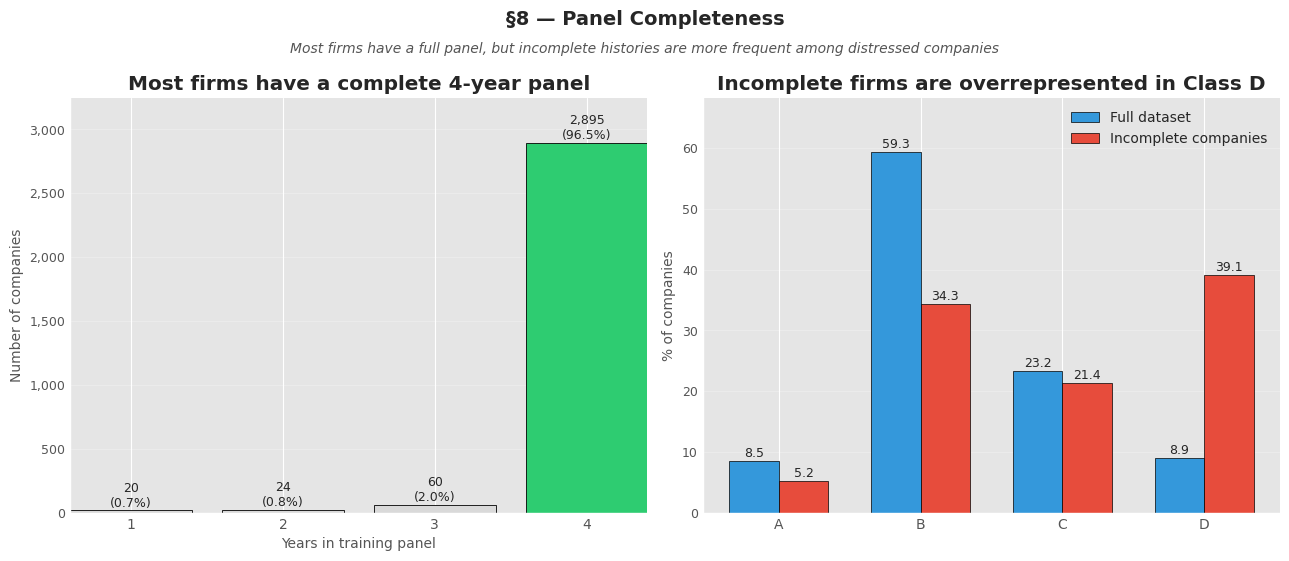

In [245]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

# years per company
colors = ["#d9d9d9", "#d9d9d9", "#d9d9d9", "#2ecc71"]
bars = axes[0].bar(
    vc.index, vc.values,
    color=colors[:len(vc)],
    edgecolor="black",
    linewidth=0.6
)

axes[0].set_xlabel("Years in training panel")
axes[0].set_ylabel("Number of companies")
axes[0].set_title("Most firms have a complete 4-year panel", fontweight="bold")
axes[0].set_xticks(vc.index)
axes[0].set_xlim(0.6, 4.4)
axes[0].set_ylim(0, vc.max() * 1.12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, (yr, cnt) in zip(bars, vc.items()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        cnt + vc.max() * 0.01,
        f"{cnt:,}\n({cnt/len(years_per)*100:.1f}%)",
        ha="center",
        fontsize=9
    )

# class distribution incomplete vs full
class_full = (
    df["financial_health_class"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(CLASS_ORDER)
)

class_inc = (
    inc_df["financial_health_class"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(CLASS_ORDER)
    .fillna(0)
)

x = np.arange(len(CLASS_ORDER))
w = 0.35

bars1 = axes[1].bar(
    x - w/2, class_full.values,
    width=w,
    label="Full dataset",
    color="#3498db",
    edgecolor="black",
    linewidth=0.5
)
bars2 = axes[1].bar(
    x + w/2, class_inc.values,
    width=w,
    label="Incomplete companies",
    color="#e74c3c",
    edgecolor="black",
    linewidth=0.5
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_ORDER)
axes[1].set_ylabel("% of companies")
axes[1].set_ylim(0, max(class_full.max(), class_inc.max()) * 1.15)
axes[1].set_title("Incomplete firms are overrepresented in Class D", fontweight="bold")
axes[1].legend(frameon=False, loc="upper right")

for bar in bars1:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.7,
        f"{bar.get_height():.1f}",
        ha="center",
        fontsize=9
    )

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.7,
        f"{bar.get_height():.1f}",
        ha="center",
        fontsize=9
    )

for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

fig.suptitle("§8 — Panel Completeness", fontsize=14, fontweight="bold", y=1.03)
fig.text(
    0.5, 0.95,
    "Most firms have a full panel, but incomplete histories are more frequent among distressed companies",
    ha="center", fontsize=10, color="#555555", style="italic"
)

fig.tight_layout()
fig.savefig(FIG_DIR / "eda_s8_panel.png", dpi=150, bbox_inches="tight")
plt.show()

§9 Sector & Geography

In [246]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

CLASS_ORDER = ["A", "B", "C", "D"]
PALETTE     = {"A": "#2ecc71", "B": "#3498db", "C": "#f39c12", "D": "#e74c3c"}

df = train_df.copy()
df["financial_health_class"] = pd.Categorical(
    df["financial_health_class"], categories=CLASS_ORDER, ordered=True
)

In [247]:
# top 10 sectors by observation count
top10 = df["ateco_sector"].value_counts().nlargest(10).index.tolist()
sector_df = df[df["ateco_sector"].isin(top10)].copy()


In [248]:
# rare sectors (< 50 obs)
sector_counts = df["ateco_sector"].value_counts()
rare_sectors  = sector_counts[sector_counts < 50].index.tolist()
print(f"Rare sectors (<50 obs): {len(rare_sectors)}  →  will be grouped into 'OTHER'")
print(f"Observations affected:  {sector_counts[rare_sectors].sum():,}  "
      f"({sector_counts[rare_sectors].sum()/len(df)*100:.1f}%)\n")

Rare sectors (<50 obs): 0  →  will be grouped into 'OTHER'
Observations affected:  0  (0.0%)



In [249]:
# D-rate per top-10 sector
ct = (
    sector_df.groupby(["ateco_sector", "financial_health_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER)
)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
d_rate = ct_pct["D"].sort_values(ascending=False)
print("D-class rate by top-10 ATECO sector (%):")
print(d_rate.round(1).to_string())

D-class rate by top-10 ATECO sector (%):
ateco_sector
10    10.5
43    10.2
47     9.9
56     9.4
46     9.2
41     9.2
71     8.2
45     8.2
25     8.1
62     6.4


In [250]:
# years_in_business median per class
yib_med = df.groupby("financial_health_class")["years_in_business"].median()
print(f"\nMedian years_in_business by class:")
print(yib_med.round(1).to_string())


Median years_in_business by class:
financial_health_class
A    36.0
B    34.0
C    36.0
D    37.0


In [251]:
# sector median ROI / ROE
sector_stats = (
    sector_df.groupby("ateco_sector")[["roi", "roe"]]
    .median()
    .sort_values("roi", ascending=False)
)
print(f"\nMedian ROI & ROE by top-10 ATECO sector:")
print(sector_stats.round(3).to_string())


Median ROI & ROE by top-10 ATECO sector:
                roi    roe
ateco_sector              
56            0.189  0.417
47            0.180  0.400
46            0.176  0.401
62            0.093  0.187
41            0.092  0.179
45            0.092  0.176
10            0.090  0.176
25            0.089  0.182
43            0.089  0.179
71            0.086  0.168


/var/folders/10/5pr64d916tn68kkg36yw_6080000gn/T/ipykernel_2032/2582178449.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


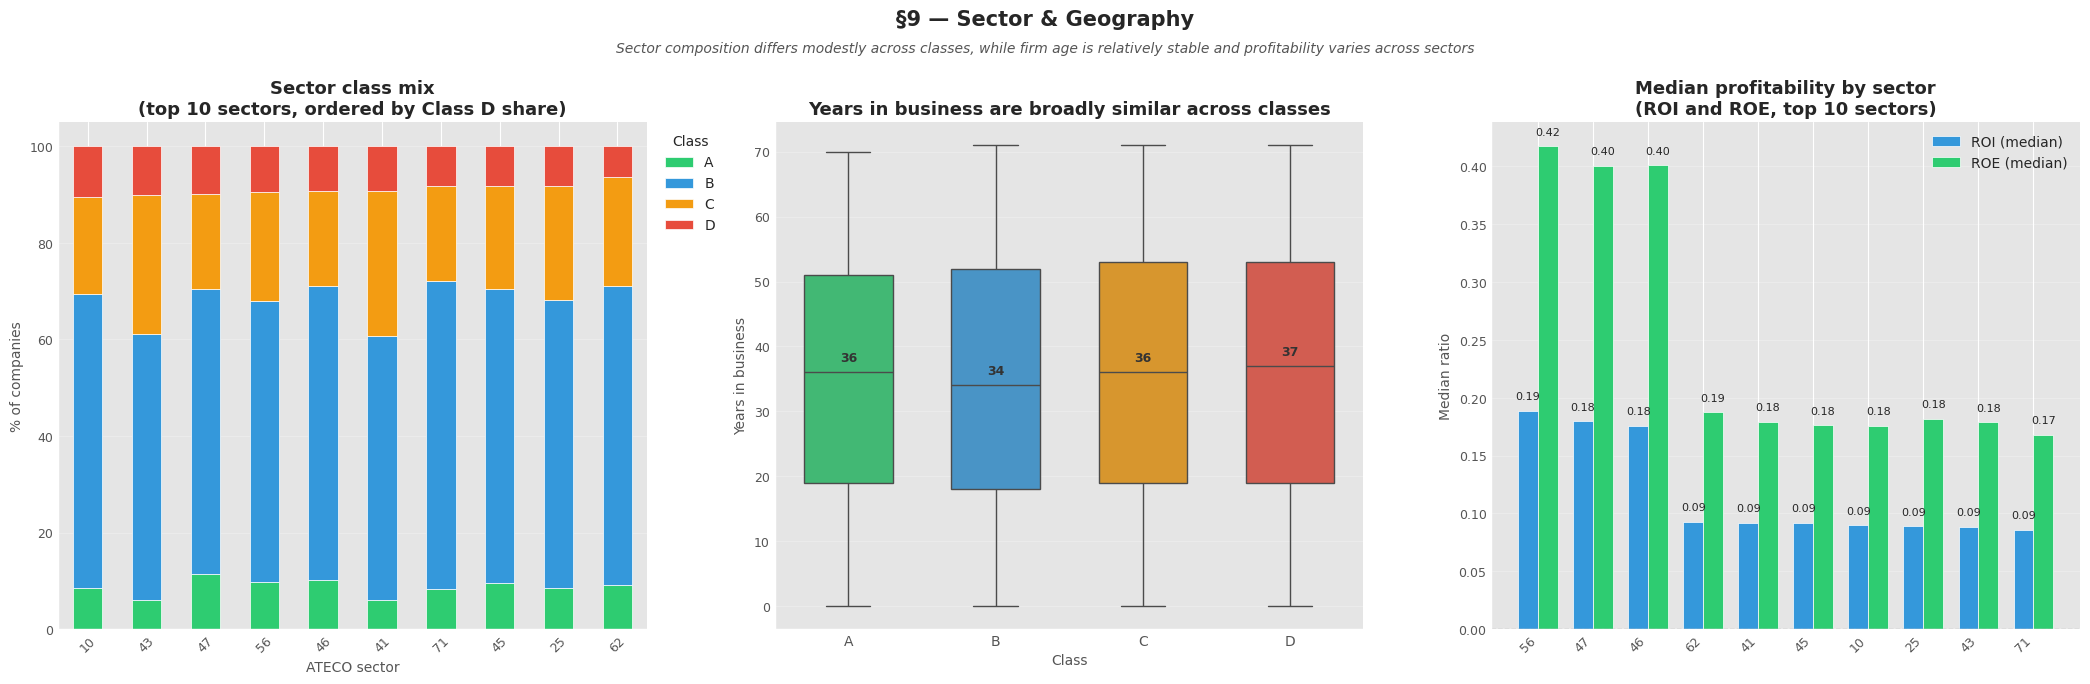

In [252]:
# plots
fig, axes = plt.subplots(1, 3, figsize=(21, 6.6))

# Stacked bar — class distribution by sector
ct_pct_sorted = ct_pct.loc[d_rate.index]

ct_pct_sorted[CLASS_ORDER].plot(
    kind="bar",
    stacked=True,
    color=[PALETTE[c] for c in CLASS_ORDER],
    edgecolor="white",
    linewidth=0.5,
    ax=axes[0],
)

axes[0].set_title(
    "Sector class mix\n(top 10 sectors, ordered by Class D share)",
    fontweight="bold",
    fontsize=13
)
axes[0].set_xlabel("ATECO sector")
axes[0].set_ylabel("% of companies")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=45, labelsize=9)
axes[0].grid(axis="y", alpha=0.25)
axes[0].set_axisbelow(True)

# legend
axes[0].legend(
    title="Class",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False
)

# Boxplot — years in business by class
box_df = df[["financial_health_class", "years_in_business"]].dropna()

sns.boxplot(
    data=box_df,
    x="financial_health_class",
    y="years_in_business",
    order=CLASS_ORDER,
    palette=PALETTE,
    width=0.6,
    linewidth=1.0,
    flierprops=dict(marker=".", markersize=1.8, alpha=0.18),
    ax=axes[1],
)

axes[1].set_title(
    "Years in business are broadly similar across classes",
    fontweight="bold",
    fontsize=13
)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Years in business")
axes[1].grid(axis="y", alpha=0.25)
axes[1].set_axisbelow(True)

# annotate medians
medians = (
    box_df.groupby("financial_health_class")["years_in_business"]
    .median()
    .reindex(CLASS_ORDER)
)

for i, cls in enumerate(CLASS_ORDER):
    axes[1].text(
        i,
        medians[cls] + 1.2,
        f"{medians[cls]:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#333333"
    )

# Grouped bar — median ROI & ROE by sector
x = np.arange(len(sector_stats))
w = 0.36

bars_roi = axes[2].bar(
    x - w/2,
    sector_stats["roi"],
    width=w,
    label="ROI (median)",
    color="#3498db",
    edgecolor="white",
    linewidth=0.5
)

bars_roe = axes[2].bar(
    x + w/2,
    sector_stats["roe"],
    width=w,
    label="ROE (median)",
    color="#2ecc71",
    edgecolor="white",
    linewidth=0.5
)

axes[2].axhline(0, color="#666666", linewidth=0.9, linestyle="--")
axes[2].set_xticks(x)
axes[2].set_xticklabels(sector_stats.index, rotation=45, ha="right", fontsize=9)
axes[2].set_title(
    "Median profitability by sector\n(ROI and ROE, top 10 sectors)",
    fontweight="bold",
    fontsize=13
)
axes[2].set_ylabel("Median ratio")
axes[2].grid(axis="y", alpha=0.25)
axes[2].set_axisbelow(True)
axes[2].legend(frameon=False, loc="upper right")

# annotate values
for bars in [bars_roi, bars_roe]:
    for bar in bars:
        h = bar.get_height()
        axes[2].text(
            bar.get_x() + bar.get_width()/2,
            h + 0.008 if h >= 0 else h - 0.015,
            f"{h:.2f}",
            ha="center",
            va="bottom" if h >= 0 else "top",
            fontsize=8
        )

# Title and subtitle
fig.suptitle(
    "§9 — Sector & Geography",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

fig.text(
    0.5, 0.965,
    "Sector composition differs modestly across classes, while firm age is relatively stable and profitability varies across sectors",
    ha="center",
    fontsize=10,
    color="#555555",
    style="italic"
)

plt.tight_layout()
plt.savefig(FIG_DIR / "eda_s9_sector.png", dpi=150, bbox_inches="tight")
plt.show()